# Code for "Managing an Energy Shock"

## Setup

### Install packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sequence_jacobian as sj
import seaborn as sns
#%% Patch SS three-value bracket
import sequence_jacobian.blocks.support.steady_state as _ss
import sequence_jacobian.blocks.block as _blk
_orig = _ss.provide_solver_default
def _patched(unknowns):
    if len(unknowns) > 1:
        return "broyden_custom"      # accept (min, guess, max) tuples
    return _orig(unknowns)
_ss.provide_solver_default = _blk.provide_solver_default = _patched

### Figure options

In [2]:
greenslide='#008C00'
redslide='#A00000'
blueslide='#0000A0'
cpalette=sns.color_palette("cubehelix", 5)

plt.rcParams['axes.xmargin'] = 0
plt.rc('text', usetex=True)
plt.rc('text.latex', preamble=r'\usepackage{mathpazo}')
plt.rc('font', family = 'serif')
plt.rc('font', size=12)

### Plot function

In [3]:
def make_plot(irfs_list, panels, titles=None, labels=None, Tplot=31, figsize=None, filename='test', savefig=False, colors=None, linestyles=None, markers=None, ylims=None, ylabels=None, legend_counter=1, leg_loc='upper right', plot_missing=False, xticks={}):
    rows, cols = panels.shape
    if figsize == None:
        figsize = (4.2*cols, 4*rows)
    plt.figure(figsize=figsize)
    if titles is None:
        titles = np.char.replace(panels,'_','-')
    if type(irfs_list) is not list:
        irfs_list = [irfs_list]
    if labels is None:
        labels = [''] * len(irfs_list)
    if colors is None:
        if len(irfs_list) == 1:
            colors = ['black']
        else:
            colors = [redslide, blueslide, greenslide] * len(irfs_list)
            colors = colors[:len(irfs_list)]
    if filename != 'test':
        savefig = True
    if linestyles is None:
        linestyles = ['-', '--', 'dashdot'] * len(irfs_list)
        linestyles = linestyles[:len(irfs_list)]
    if markers == None:
        markers = [None] * len(irfs_list)
    counter = 0
    for i in range(rows):
        for j in range(cols):
            counter += 1
            if panels[i, j] != '':
                plt.subplot(rows, cols, counter)
                plt.title(titles[i, j])
                plt.axhline(y=0, color='#808080', linestyle=':')
                for irfs, label, linestyle, color, marker in zip(irfs_list, labels, linestyles, colors, markers):
                    if panels[i, j] in irfs:
                        plt.plot(100 * irfs[panels[i, j]][:Tplot], linestyle=linestyle, color=color, label=label, marker=marker)
                    else:
                        if plot_missing:
                            plt.plot(np.zeros((Tplot)), linestyle=linestyle, color=color, label=label, marker=marker)
                
                plt.xlabel('Quarters')
                
                if xticks != {}:
                    plt.xticks(ticks=xticks['locs'],labels=xticks['labels'])
                
                if counter == legend_counter:
                    plt.legend(framealpha=0, loc=leg_loc)
                if ylabels is not None:
                    plt.ylabel(ylabels[counter-1])
                else:
                    plt.ylabel('Percent')
                if isinstance(ylims, dict):
                    if panels[i, j] in ylims:
                        plt.ylim(ylims[panels[i, j]])
                elif ylims is not None:
                    plt.ylim(ylims[counter-1])

    plt.tight_layout()
#     if savefig: plt.savefig('Figures/' + filename + '.pdf', format='pdf', transparent=True)
    plt.show()

## Calibration

### Baseline

In [4]:
calibration = dict(r = 0.01,            # Real interest rate
                   eis = 1,             # Elasticity of intertemporal substitution
                   eta_E = 0.1,         # Elasticity of Energy with (H, F) bundles (outer nest)
                   frisch = 0.5,        # Elasticity of labor supply
                   alpha_E = 0.04,      # Spending share on imported E energy
                   E_supply_elasticity = np.inf,  # Supply elasticity of imports (SOE: infinite)
                   markup_ss = 1.03,    
                   sd_e = 0.57,
                   rho_e = 0.92,
                   n_e = 7,             # Number of income states
                   n_beta = 3,          # Number of betas
                   beta_spread = 0.06,  # Spread between betas
                   beta_max = 0.95,
                   min_a = 0, max_a = 400, n_a = 150, # Asset grid
                   zetaF = 0, zetaE = 0, zetaEsupply=0,
                   prodE_es=0.1,
                   theta_E = 0.65,
                   theta_F=0.9
                   )

### Targets

In [5]:
calibration['alpha'] = 0.3
chi_target = 0.3

### Model options

In [6]:
# Monetary policy rule
calibration.update({'rho_i': 0, 'phi_pi': 0, 'phi_pie': 1, 'phi_piw': 0}) # Real rate rule

# Fiscal policy
calibration.update({'B': 0, 'psiB': 0.04, 'tauY': 0, 'epsT': 0, 'insE': 0, 'tauE': 0, 'bb': 0}) 

# Real wage rigidity
calibration.update({'w_BG': 5}) # real wage smoothing motive, 0 = none

# International supply
calibration.update({'Gamma_arb': 100}) # intertemporal arbitrage, inf = none

# Other
calibration.update(dict(ghh_prefs=0,  # use GHH preferences? 0 = no
                        w_index=0,    # wage indexation parameter, 0 = no indexation to past CPI inflation, 1 = full indexation
                        scale_w=0,    # whether non-homotheticity scales with wage ( = 1) or is lump sum ( = 0)
                        cbarE=0,      # is this non-homotheticity?
                        eps_dcp=1,    # ad hoc dampening factor dampening gamma?
                        pcX_home=1,   # where are profits booked?
                        wealth_effect=1, # wealth effect in union wedge
                        prodE_share=0, # is energy used in production?
                        lambda_c = 0.25 # share of constrained agents in TA model
                       ))

### Matching targets

In [7]:
# Openness
calibration['alpha_F'] = (calibration['alpha']-calibration['alpha_E'])/(1-calibration['alpha_E'])
# Spending share on imported F products
calibration['alpha_F_tilde'] = (1-calibration['alpha_E'])*calibration['alpha_F']
# Elasticity of export demand
calibration['gamma'] = (chi_target - (1-calibration['alpha'])*(1-calibration['alpha_F'])*calibration['eta_E']) / ((1-calibration['alpha'])*calibration['alpha_F'] + calibration['alpha'])
# Elasticity of substitution between H and F (inner nest)
calibration['eta'] = calibration['gamma']

### Normalizations

In [8]:
calibration.update(
        {'Q': 1, 'y': 1, 'ishock': 0, 'Cstar': 1, 'piw': 0, 'pi':0, 'P': 1, 'B': 0, 'nfa': 0, 'PFstar': 1, 'W': 1, 'Z': calibration['markup_ss'],
         'rstar': calibration['r'], 'pH_PHF': 1, 'pHstar': 1, 'pF_PHF': 1, 'pEhh_P': 1, 'pHF_P': 1, 'dividend_X': 0, 'vphi': 1,
         'rante': calibration['r'], 'beta_RA': 1/(1+calibration['r']), 'C': 1, 'A': 1, 'w':1, 
         'alphastar': calibration['alpha'], 'E_supply_shock': calibration['alpha_E']})

calibration.update(dict(
    PEstar_shock = 1,  # shock to dollar price of E
    PEstar = 1,  # dollar price of E
    PFstar = 1,  # dollar price of F
    inom_t = 0,
    union_wedge = 0
))

calibration['cE_ss_grid_0'] = np.zeros((calibration['n_e'],calibration['n_a']))
calibration['cE_ss_grid_1'] = np.zeros((calibration['n_e'],calibration['n_a']))
calibration['cE_ss_grid_2'] = np.zeros((calibration['n_e'],calibration['n_a']))
calibration['cE_ss'] = 0
calibration['c_ss_grid_0'] = np.ones((calibration['n_e'],calibration['n_a']))
calibration['c_ss_grid_1'] = np.ones((calibration['n_e'],calibration['n_a']))
calibration['c_ss_grid_2'] = np.ones((calibration['n_e'],calibration['n_a']))

### Adjustment for energy endowment

In [9]:
# If you want energy endowment in baseline
markup_original = calibration['markup_ss']
zetaEsupply = 0.33
calibration.update({'zetaEsupply':zetaEsupply,
                    'y': 1-zetaEsupply*calibration['alpha_E'],
                    'markup_ss': calibration['markup_ss'] * (1-zetaEsupply*calibration['alpha_E']),
                    'alphastar': calibration['alpha'] - calibration['alpha_E']*zetaEsupply,
                    'Z': calibration['markup_ss'] * (1-zetaEsupply*calibration['alpha_E'])})

# To achieve piw
calibration.update({'theta_w': 0.938})

## Blocks

### HA household

In [10]:
def hh_init(coh, r, eis):
    Va = (1 + r) * (0.1 * coh) ** (-1 / eis)
    return Va

@sj.het(exogenous='Pi', policy='a', backward='Va', backward_init=hh_init)
def hh(Va_p, a_grid, r, beta_g, eis, coh, ghh):
    uc_nextgrid = beta_g * Va_p
    c_nextgrid = uc_nextgrid ** (-eis) + ghh
    a = sj.interpolate.interpolate_y(c_nextgrid + a_grid, coh, a_grid)
    sj.misc.setmin(a, a_grid[0])
    c = coh - a
    Va = (1 + r) * (c - ghh) ** (-1 / eis)
    return Va, a, c

def make_grids(rho_e, sd_e, n_e, min_a, max_a, n_a):
    e_grid, _, Pi = sj.grids.markov_rouwenhorst(rho_e, sd_e, n_e)
    a_grid = sj.grids.asset_grid(min_a, max_a, n_a)
    return e_grid, Pi, a_grid

def hh_income(e_grid, atw_n, r, pEhh_P, cbarE, scale_w, markup_ss, a_grid, n, frisch, ghh_prefs, epsT, cE_ss_grid, insE, pE_P, pE_P_ss):
    Tf = - pEhh_P * cbarE * (atw_n * markup_ss) * scale_w - pEhh_P * cbarE * (1 - scale_w)
    Tfiscal = epsT + insE * (pE_P - pE_P_ss) * cE_ss_grid
    coh = (1 + r) * a_grid + atw_n * e_grid[:, np.newaxis] + Tf + Tfiscal
    n_ss = 1
    ghh = ghh_prefs * 1/(1+1/frisch) * (n**(1+1/frisch) - n_ss**(1+1/frisch))
    return coh, ghh

def compute_weighted_mpc(c, a_grid, r, e_grid):
    """Approximate mpc out of wealth, with symmetric differences where possible, exactly setting mpc=1 for constrained agents."""
    mpc = np.empty_like(c)
    post_return = (1 + r) * a_grid
    mpc[:, 1:-1] = (c[:, 2:] - c[:, 0:-2]) / (post_return[2:] - post_return[:-2])
    mpc[:, 0] = (c[:, 1] - c[:, 0]) / (post_return[1] - post_return[0])
    mpc[:, -1] = (c[:, -1] - c[:, -2]) / (post_return[-1] - post_return[-2])
    # mpc[a == a_grid[0]] = 1
    mpc = mpc * e_grid[:, np.newaxis]
    return mpc

def inequality(c, c_ss_grid):
    c2 = c ** 2 
    logc = np.log(c)
    logc2 = np.log(c) ** 2 
    
    diff_c = c - c_ss_grid
    diff_c2 = (c - c_ss_grid) ** 2
    diff_logc = np.log(c) - np.log(c_ss_grid)
    diff_logc2 = (np.log(c) - np.log(c_ss_grid)) ** 2
    return c2, logc, logc2, diff_c, diff_c2, diff_logc, diff_logc2

hh_ha = hh.add_hetinputs([make_grids, hh_income]).add_hetoutputs([compute_weighted_mpc, inequality])
group_vars = ['C','A','MPC','cE_ss_grid','c_ss_grid','C2','LOGC2','LOGC', 'DIFF_C', 'DIFF_C2', 'DIFF_LOGC', 'DIFF_LOGC2']
hh_ha_list = [hh_ha.rename(suffix=f'_{i}').remap({f'{x}': f'{x}_{i}' for x in group_vars}).remap({'beta_g': f'beta_{i}'}) for i in range(3)]

@sj.simple
def group_betas(beta_spread,beta_max,n_beta):
    beta_2 = beta_max
    beta_1 = beta_max - beta_spread/2
    beta_0 = beta_max - beta_spread
    return beta_0, beta_1, beta_2

@sj.simple
def aggregate_groups(C_0,C_1,C_2,A_0,A_1,A_2,MPC_0,MPC_1,MPC_2,beta_0, beta_1, beta_2):
    C = (C_0+C_1+C_2)/3
    A = (A_0+A_1+A_2)/3
    MPC = (MPC_0+MPC_1+MPC_2)/3
    beta = (beta_0+beta_1+beta_2)/3
    return C, A, MPC, beta

hh_ha = sj.create_model(hh_ha_list+[group_betas,aggregate_groups])

### RA household

In [11]:
@sj.solved(unknowns={'C': 1, 'A': 1}, targets=['euler', 'budget'])
def hh_ra(C, A, beta_RA, rante, r, eis, atw_n, markup_ss, scale_w, pEhh_P, cbarE, epsT, insE, PE, cE_ss, P, ghh_prefs, frisch, n):
    ghh = ghh_prefs * 1/(1+1/frisch) * (n**(1+1/frisch) - n.ss**(1+1/frisch))
    MU = (C - ghh)**(-1/eis)
    euler = beta_RA * (1+rante) * MU(1) - MU
    Tfiscal = epsT + insE * (PE - PE.ss) * cE_ss / P
    Tf = - pEhh_P * cbarE * (atw_n * markup_ss) * scale_w - pEhh_P * cbarE * (1 - scale_w)
    budget = (1 + r) * A(-1) + atw_n + Tf + Tfiscal - C - A
    beta = beta_RA
    return euler, budget, beta

In [12]:
@sj.solved(unknowns={'A': 1., 'H': 100., 'R_sum': 1., 'G':0.}, targets=['budget', 'H_t', 'R_sum_t', 'G_t'])
def hh_ra_im(atw_n,r,beta_RA,eis,epsT,insE,PE,cE_ss,P,pEhh_P,cbarE,markup_ss,scale_w,A,H,R_sum,G, n):
    U_CN_CC = 0 # change if you want option to make GHH
    U_C_CC = - eis # change if you want option to make GHH
    
    Tfiscal = epsT + insE * (PE - PE.ss) * cE_ss / P
    Tf = - pEhh_P * cbarE * (atw_n * markup_ss) * scale_w - pEhh_P * cbarE * (1 - scale_w)
    income = atw_n + Tf + Tfiscal
    
    C = (1 - beta_RA) * ((1+r)*A(-1) + H + U_CN_CC*G) + ((1-beta_RA)*A + beta_RA * U_C_CC) * (R_sum - 1)
    
    budget = (1 + r) * A(-1) + income - C - A
    H_t = income + beta_RA * H(1) - H
    G_t = (beta_RA/(1-beta_RA))*(n(1) - n) + beta_RA * G(1) - G
    R_sum_t = beta_RA * (r(1) + R_sum(1)) - R_sum
    beta = beta_RA
    return C, beta, budget, H_t, G_t, R_sum_t

### TA household

In [13]:
@sj.solved(unknowns={'C_u': 1, 'A_u': 1}, targets=['euler', 'budget'])
def hh_ta(C_u, A_u, beta_RA, rante, r, eis, atw_n, epsT, insE, PE, P, cE_ss, lambda_c):
    MU = (C_u)**(-1/eis)
    euler = beta_RA * (1+rante) * MU(1) - MU
    Tfiscal = epsT + insE * (PE - PE.ss) * cE_ss / P
    budget = (1 + r) * A_u(-1) + atw_n + Tfiscal - C_u - A_u
    beta = beta_RA
    
    C_c = atw_n + Tfiscal
    C = lambda_c * C_c + (1-lambda_c) * C_u
    A = (1-lambda_c) * A_u
    return euler, budget, beta, C_c, C, A 

### Good specific demands

In [14]:
@sj.simple
def hh_outputs(C, atw_n, pH_PHF, pEhh_P, pF_PHF, pHF_P, eta, eta_E, alpha_E, alpha_F, markup_ss, cbarE, scale_w):
    alpha_F_tilde = (1-alpha_E)*alpha_F
    cH = (1-alpha_E - alpha_F_tilde) * (pH_PHF)**(-eta) * pHF_P**(-eta_E) * C
    cF = alpha_F_tilde * (pF_PHF)**(-eta) * pHF_P**(-eta_E) * C
    cE = cbarE*(atw_n*markup_ss)*scale_w + cbarE*(1-scale_w) + alpha_E * pEhh_P**(-eta_E) * C
    return cH, cF, cE

### Home firms

In [15]:
@sj.solved(unknowns={'J': 15., 'j': 15.}, targets=['Jres', 'jres'], solver="broyden_custom")
def income(y, w, Z, pH_P, pE_P, J, j, rante, dividend_X, tauY, pcX_home, markup_ss, prodE_share, prodE_es):
    
    prodE = prodE_share * (pH_P/pE_P) ** prodE_es * y
    
    if prodE_share == 0:
        n = y / Z 
    else:
        n = (1-prodE_share) * (y/Z) * ((markup_ss * w) / (Z * pH_P)) ** (-prodE_es)
        
    btw_n = w * n 
    atw_n = (1-tauY) * btw_n
    atw = atw_n / n
    gdp = Z * n
    
    dividend = (markup_ss - 1) * w * n

    div_tot = dividend
    if pcX_home == 1: div_tot += dividend_X
    Jres = div_tot + J(1) / (1 + rante) - J
    jres = J(1) / (1 + rante) - j
    
    return jres, Jres, atw_n, dividend, gdp, atw, n, btw_n, prodE

In [16]:
@sj.simple
def profitcenters(Q, pH_P, cHstar, eps_dcp):
    dividend_X = (Q ** (1 - eps_dcp) * pH_P ** (eps_dcp) - pH_P) * cHstar
    return dividend_X

### Importers

Maybe make beta_F dynamic. (Would only matter for nonlinear with importers and non-RR MP.)

In [17]:
@sj.solved(unknowns={'piF':0.,'PF':1.}, targets=['piF_res','PFres'], solver="broyden_custom")
def foreignPrices(piF,PF,P,Q,PFstar,rante,theta_F):
    PFres = (1+piF) * PF(-1) - PF
    pF_P = PF / P
    beta_F = 1/(1+rante.ss)
    kappa_F = (1 - theta_F) * (1 - beta_F * theta_F) / theta_F
    piF_term = Q * PFstar / pF_P - 1
    piF_res = kappa_F * piF_term + beta_F * piF(1) * (1+piF(1)) - piF * (1+piF) 
    return piF_res, PFres, pF_P

@sj.solved(unknowns={'piE':(-0.5,0.,1.),'PE':(0.1,1.,5.)}, targets=['piE_res','PEres'], solver="broyden_custom")
def energyPrices(piE,PE,P,Q,PEstar,rante,theta_E,tauE):
    PEres = (1+piE) * PE(-1) - PE
    pE_P = PE / P
    beta_E = 1/(1+rante.ss)
    kappa_E = (1 - theta_E) * (1 - beta_E * theta_E) / theta_E
    piE_term = Q * PEstar / pE_P - 1
    piE_res = kappa_E * piE_term + beta_E * piE(1) * (1+piE(1)) - piE * (1+piE)
    
    pE_P_ss = pE_P.ss # Looks like you cant use PE.ss inside a het input(?)
    pEhh_P = (1-tauE) * pE_P + tauE * pE_P.ss
    pEhh = pEhh_P * P
    return piE_res, PEres, pE_P, pE_P_ss, pEhh_P, pEhh

importPrices = sj.combine([foreignPrices,energyPrices])

In [18]:
@sj.solved(unknowns={'JF': 0., 'JE': 0}, targets=['JF_res', 'JE_res'], solver="broyden_custom")
def importProfits(JF, JE, pF_P, pE_P, Q, PFstar, PEstar, cF, cE, prodE, rante):
    DF = (pF_P - Q * PFstar) * cF
    JF_res = DF + JF(1)/(1+rante) - JF
    jF = JF(1)/(1+rante)
    
    DE = (pE_P - Q * PEstar) * (cE + prodE)
    JE_res = DE + JE(1)/(1+rante) - JE
    jE = JE(1)/(1+rante)
    return JF_res, jF, JE_res, jE, DF, DE

### Household ex post interest rate

In [19]:
@sj.simple
def revaluation(r, j, J, jF, JF, zetaF, jE, JE, zetaE,j_Esupply,J_Esupply,zetaEsupply):
    r_res = (J + zetaF * JF + zetaE * JE + zetaEsupply * J_Esupply)/(j(-1) + zetaF * jF(-1) + zetaE * jE(-1) + zetaEsupply * j_Esupply(-1)) - 1 - r
    return r_res 

### Foreign demand

In [20]:
@sj.simple
def foreign_c(pHstar, alphastar, gamma, Cstar, eps_dcp):
    cHstar = alphastar * pHstar ** (-gamma * eps_dcp) * Cstar
    return cHstar

### UIP

In [21]:
@sj.solved(unknowns={'Q': (0.1, 2)}, targets=['uip'])
def UIP(Q, rante, rstar):
    uip = Q / Q(+1) * (1 + rante) - (1 + rstar)
    return uip

### Unions

In [22]:
@sj.solved(unknowns={'piw': (-2, 2)}, targets=['piwres'], solver="brentq")
def unions(n,C,atw,w,vphi,w_BG,theta_w,beta,markup_ss,frisch,eis,piw,union_wedge):
    kappa_w = (1 - theta_w) * (1 - beta * theta_w) / theta_w
    psi_nr_inv = kappa_w  / (vphi * (n**(1+(1/frisch))))
    
    BG_term = (w-w.ss)*w * C.ss**(-1/eis) * n.ss / (markup_ss * n * w.ss)
    piwterm = vphi * n ** (1/frisch) - (atw*(C**(-1/eis)))/markup_ss - w_BG * BG_term + union_wedge
    piwres = piw*(1+piw) - beta*piw(1)*(1+piw(1)) - psi_nr_inv * n * piwterm
    
    return piwres, piwterm

@sj.solved(unknowns={'W': (0.5, 2)}, targets=['Wres'], solver="brentq")
def piW_to_W(piw,W):
    Wres = W(-1) * (1 + piw) - W
    return Wres

### Prices and Inflation

In [23]:
@sj.solved(unknowns={'pHF_P': 1., 'pH_PHF': 1.}, targets=['inner_nest', 'outer_nest'])
def CESprices(Q, eta, alpha_F, gamma, PFstar, PEstar, pHF_P, pH_PHF, eta_E, alpha_E, pEhh_P, pF_P):

    alpha = alpha_E + (1-alpha_E)*alpha_F
    
    pF_PHF = pF_P / pHF_P
    pH_P = pH_PHF * pHF_P
    pHstar = pH_P / Q

    # next define the nests
    if eta_E == 1:
        inner_nest = (pHF_P) ** (1 - alpha_E) * (pEhh_P) ** alpha_E - 1
    else:
        inner_nest = (1 - alpha_E) * (pHF_P) ** (1 - eta_E) + alpha_E * (pEhh_P) ** (1 - eta_E) - 1

    if eta == 1:
        outer_nest = (pH_PHF) ** (1 - alpha_F) * (pF_PHF) ** alpha_F - 1
    else:
        outer_nest = (1-alpha_F) * (pH_PHF)**(1-eta) + alpha_F * (pF_PHF)**(1-eta) - 1

    chi_tilde = (1-alpha) * (alpha_F * eta + (1-alpha_F) * eta_E) + alpha*gamma
    return chi_tilde, pF_PHF, inner_nest, outer_nest, pH_P, pHstar, alpha

In [24]:
@sj.simple
def price_levels(piw, W, w, Z, pH_P, Q, P, PE, markup_ss, prodE_es, prodE_share):
    if prodE_es == 1:
        PH = (markup_ss / Z * W) ** (1-prodE_share) * PE ** prodE_share
    else:
        PH = ((1-prodE_share)*(markup_ss / Z * W)**(1-prodE_es) + prodE_share*(PE)**(1-prodE_es)) ** (1/(1-prodE_es))
    
    pires = PH / pH_P - P
    E = P * Q 
    piH = PH / PH(-1) - 1
    w_res = W / P - w
    return PH, pires, E, piH, w_res

In [25]:
@sj.simple
def annualize(pi, piw, inom, r, rante):
    pi_ann = (1+pi) ** 4 - 1 
    piw_ann = (1+piw) ** 4 - 1
    inom_ann = (1+inom) ** 4 - 1
    r_ann = (1+r) ** 4 - 1
    rante_ann = (1+rante) ** 4 - 1
    
    return pi_ann, piw_ann, inom_ann, r_ann, rante_ann

In [26]:
@sj.solved(unknowns={'P': (0.5, 2)}, targets=['Pres'])
def pitop(P,pi):   
    Pres = P - (1+pi)*P(-1)
    return Pres

### Monetary policy

In [27]:
@sj.solved(unknowns={'inom': (-1, 1)}, targets=['inom_res'])
def mon_policy(ishock, rstar, pi, phi_pi, phi_pie, rho_i, inom, phi_piw, w, P, inom_t):
    W_here = w * P
    piw_here = (W_here/W_here(-1)) - 1
    inom_res = -(1+inom) + rho_i * (1+inom(-1)) + (1-rho_i) * (1 + rstar.ss) * (1 + phi_pi * pi) * (1 + phi_piw * piw_here) * (1 + phi_pie * pi(+1)) + ishock
    rante = (1 + inom)/(1 + pi(+1)) - 1
    inom_t_res = inom - inom_t # if you want to choose ishock to target a particular path for nominal rates
    return rante, inom_res, inom_t_res


### Fiscal policy

In [28]:
@sj.solved(unknowns={'B': (-1, 1)}, targets=['B_res'])
def fiscal(B, rante, btw_n, psiB, tauY, epsT, insE, pE_P, cE, tauE, bb):
    Tuntargeted = epsT
    Ttargeted = insE * (pE_P - pE_P.ss) * cE.ss 
    Subsidy = tauE * (pE_P - pE_P.ss) * cE 
    
    spending = Tuntargeted + Ttargeted + Subsidy
    taxation = tauY * btw_n
    
    B_res = (1 + rante(-1)) * B(-1) + spending - taxation - B
    tauY_res = (1-bb)*(psiB * (B(-1) - B.ss) - tauY) + bb*(B-B.ss)
    return B_res, tauY_res, Tuntargeted, Ttargeted, spending, taxation

### Trade

In [29]:
@sj.solved(unknowns={'nfa': (-2, 2)}, targets=['nfares'], solver="brentq")
def CA(nfa, Q, pHstar, cHstar, PFstar, cF, PEstar, cE, prodE, rante, r, A, rdom, Adom,zetaEsupply,E_supply,y):
    exports = Q * (pHstar * cHstar + PEstar * zetaEsupply * E_supply)
    imports = Q * (PFstar * cF + PEstar * (cE+prodE))
    imports_pc = imports / imports.ss
    exports_pc = exports / exports.ss
    
    netexports = Q * (pHstar * cHstar - PFstar * cF - PEstar * (cE+prodE-zetaEsupply*E_supply))
    revaluation_term = (r - rante(-1)) * A(-1) - (rdom - rante(-1)) * Adom(-1)
    nfares = netexports + revaluation_term + (1 + rante(-1)) * nfa(-1) - nfa

    nx_gdp = netexports / y 
    return nfares, netexports, revaluation_term, exports, imports, nx_gdp, imports_pc, exports_pc

In [30]:
@sj.simple
def revaluation_dom(j, J, jF, JF, jE, JE, zetaEsupply, j_Esupply, J_Esupply):
    rdom = (J + JF + JE + zetaEsupply*J_Esupply)/(j(-1) + jF(-1) + jE(-1) + zetaEsupply*j_Esupply(-1)) - 1
    Adom = j + jF + jE + zetaEsupply*j_Esupply
    return rdom, Adom

### Intertemporal energy arbitrage

In [31]:
@sj.solved(unknowns={'J_Esupply': (0, 100)}, targets=['J_Esupply_res'])
def IEA(J_Esupply,PEstar,P,rstar,Gamma_arb,E_supply_shock, rante,Q, zetaEsupply):
    E_stock = ((PEstar(1)/(1+rstar)) - PEstar) / Gamma_arb
    E_supply = E_supply_shock + (E_stock(-1) - E_stock) 
    
    D_Esupply = Q * (PEstar * E_supply) 
    J_Esupply_res = D_Esupply + J_Esupply(1)/(1+rante) - J_Esupply
    j_Esupply = J_Esupply(1)/(1+rante)
    D_Esupply_H = zetaEsupply * D_Esupply # the dividends that go to home
    return E_supply, D_Esupply, J_Esupply_res, j_Esupply, D_Esupply_H, E_stock

### Equilibrium conditions

In [32]:
@sj.simple
def eqm_cond(y, cH, cHstar, A, gdp, nfa, j, jF, jE, B, cE, prodE, PEstar, PEstar_shock, E_supply_elasticity, E_supply_shock, E_supply, zetaF, zetaE, rante, r, Q, pHstar, PFstar, cF, netexports, E, P, DF, pF_P, DE, pE_P, pH_P, dividend, markup_ss, btw_n, J, JF, JE, zetaEsupply, j_Esupply):
    goods_clearing = cH + cHstar - y
    assets_clearing = A - nfa - j - jF - jE - B - zetaEsupply*j_Esupply
    if E_supply_elasticity == np.inf:
        E_clearing = PEstar - PEstar_shock
    else:
        E_clearing = (cE+prodE) - E_supply
    PEstar_diff = PEstar - PEstar_shock
    gdp_t = gdp - 1
    return goods_clearing, assets_clearing, E_clearing, PEstar_diff, gdp_t

## Models and Steady State

In [33]:
def test_targets(dictionary, extra_checks=[], err_tol=1e-5, noisy=False):
    for target in (['uip', 'piwres', 'nfares', 'goods_clearing', 'assets_clearing', 'Pres', 'w_res', 'E_clearing', 'inner_nest', 'outer_nest'] + extra_checks):
        assert np.isclose(np.max(dictionary[target]), 0, atol=err_tol), print(target+' : '+str(np.linalg.norm(dictionary[target])))
        if noisy:
            print(target+' : '+str(np.linalg.norm(dictionary[target])))
    return

### HA model

In [34]:
model_ha = sj.combine([hh_ha, hh_outputs, foreign_c, revaluation, mon_policy, fiscal, income, importPrices, importProfits, profitcenters, UIP, eqm_cond, CA,
                       unions, CESprices, price_levels, piW_to_W, pitop, revaluation_dom, annualize, IEA])

# Temporary fix to allow (guess_min,guess,guess_max): comment out lines 36--39 in steady_state.py. 
ss_ha = model_ha.solve_steady_state(calibration, unknowns={'vphi': 1, 'beta_max': 0.984}, targets=['piwres', 'nfares'], dissolve=['unions', 'UIP', 'CA', 'piW_to_W', 'pitop'])

test_targets(ss_ha) 

Retrieve steady state energy consumption grid for targeted policy. And steady state consumption grid for inequality measures.

(Could probably just do the latter and infer cE_ss_grid within the block...)

In [35]:
ss_ha['cE_ss_grid_0'] = ss_ha.internals['hh_0']['c'] * ss_ha['cE'] / ss_ha['C']
ss_ha['cE_ss_grid_1'] = ss_ha.internals['hh_1']['c'] * ss_ha['cE'] / ss_ha['C']
ss_ha['cE_ss_grid_2'] = ss_ha.internals['hh_2']['c'] * ss_ha['cE'] / ss_ha['C']
ss_ha['cE_ss'] = ss_ha['cE']

ss_ha['c_ss_grid_0'] = ss_ha.internals['hh_0']['c']
ss_ha['c_ss_grid_1'] = ss_ha.internals['hh_1']['c']
ss_ha['c_ss_grid_2'] = ss_ha.internals['hh_2']['c']

### TA model

In [36]:
calibration['A_u'] = ss_ha['A'] / (1-calibration['lambda_c'])

model_ta = sj.combine([hh_ta, hh_outputs, foreign_c, revaluation, mon_policy, fiscal, income, importPrices, importProfits, profitcenters, UIP, eqm_cond, CA,
                       unions, CESprices, price_levels, piW_to_W, pitop, revaluation_dom, annualize, IEA])

ss_ta = model_ta.solve_steady_state(calibration, unknowns={'vphi': 1., 'C_u': 1.}, targets=['piwres', 'budget'], dissolve=['hh_ta','unions', 'UIP', 'CA', 'piW_to_W', 'pitop'])

test_targets(ss_ta) 

### Complete-market RA model

In [37]:
model_ra = sj.combine([hh_ra, hh_outputs, foreign_c, revaluation, mon_policy, fiscal, income, importPrices, importProfits, profitcenters, UIP, eqm_cond, CA,
                       unions, CESprices, price_levels, piW_to_W, pitop, revaluation_dom, annualize, IEA])

calibration['A'] = ss_ha['A']
model_ra.steady_state(calibration, dissolve=['unions', 'hh_ra', 'UIP', 'CA', 'piW_to_W'])
ss_ra = model_ra.solve_steady_state(calibration, unknowns={'vphi': (0., 1., 2.), 'C': (0.,1.,2.)}, targets=['piwres','budget'], dissolve=['unions', 'hh_ra', 'UIP', 'CA', 'piW_to_W', 'pitop'])

test_targets(ss_ra,['euler', 'budget'])

### RA-IM model

In [38]:
model_ra_im = sj.combine([hh_ra_im, hh_outputs, foreign_c, revaluation, mon_policy, fiscal, income, importPrices, importProfits, profitcenters, UIP, eqm_cond, CA,
                          unions, CESprices, price_levels, piW_to_W, pitop, revaluation_dom, annualize, IEA])

ss_ra_im = model_ra_im.solve_steady_state(ss_ra, 
                                          unknowns={'vphi': (0.,1.,2.), 'Cstar': (0.,1.,2.), 'H': (0,100.,1000.), 'R_sum': (0,100.,1000.), 'G': (-1,0,1)}, 
                                          targets=['piwres', 'goods_clearing', 'H_t', 'R_sum_t', 'G_t'], 
                                          dissolve=['unions', 'hh_ra_im', 'UIP', 'CA', 'piW_to_W', 'pitop'])

test_targets(ss_ra_im,['budget', 'H_t', 'R_sum_t', 'G_t'])

# Dynamics

In [39]:
T = 100
unknowns_td = {'y', 'pi', 'r', 'tauY', 'PEstar','w'}
targets_td = {'goods_clearing', 'pires', 'r_res', 'tauY_res', 'E_clearing','w_res'}

n.b. only ra case is set up to handle energy in production

In [40]:
def recalib(shocks_=None, modelname='ha',unknowns_td_=unknowns_td, targets_td_=targets_td, resolve_ss=False, return_ss=False, err_tol=1e-5, analytic=False, **kwargs):
    # Unpack arguments
    if modelname == 'ha':
        model = model_ha
        ss = ss_ha.copy()
        dissolve = ['unions', 'UIP', 'CA', 'piW_to_W', 'pitop']
    elif modelname == 'ra':
        model = model_ra
        ss = ss_ra.copy()
        dissolve = ['unions', 'UIP', 'CA', 'piW_to_W', 'hh_ra', 'pitop']
    elif modelname == 'ra_im':
        model = model_ra_im
        ss = ss_ra_im.copy()
        dissolve = ['unions', 'hh_ra_im', 'UIP', 'CA', 'piW_to_W', 'pitop'] 
    elif modelname == 'ta':
        model = model_ta
        ss = ss_ta.copy()
        dissolve = ['hh_ta','unions', 'UIP', 'CA', 'piW_to_W', 'pitop']
    else:
        raise ValueError('modelname not specified properly')
    if shocks_ is None:
        shocks_ = shocks
    
    if analytic:
        # no importer frictions
        ss.update({'theta_F': 0.0001,
                   'theta_E': 0.0001})
        # no energy endowment
        original_markup = ss['markup_ss'] / (1-ss['zetaEsupply'] * ss['alpha_E'])
        ss.update({'zetaEsupply':0,
                    'y': 1,
                    'markup_ss': original_markup,
                    'alphastar': ss['alpha'],
                    'Z': original_markup})
    ss.update(kwargs)
    
    # Solve steady state
    if resolve_ss:
        if modelname=='ha':
            ss_here = model.solve_steady_state(ss, unknowns={'vphi': (0.1, 1, 2), 'beta_max': (0.95, 0.984, 0.99)}, targets=['piwres', 'nfares'], dissolve=dissolve)
        elif modelname=='ra':
            ss_here = model.solve_steady_state(ss, unknowns={'vphi': (0., 1., 2.), 'C': (0.9,1.,1.1), 'y': (0.9,1.,1.1)}, targets=['piwres','budget','gdp_t'], dissolve=dissolve)
        elif modelname == 'ra_im':
            ss_here = model.solve_steady_state(ss, unknowns={'vphi': (0.,1.,2.), 'Cstar': (0.,1.,2.), 'H': (0,100.,1000.), 'R_sum': (0,100.,1000.), 'G': (-1,0,1)}, targets=['piwres', 'goods_clearing', 'H_t', 'R_sum_t', 'G_t'], dissolve=dissolve)
        elif modelname == 'ta':
            ss_here = model.solve_steady_state(ss, unknowns={'vphi': 1., 'C_u': 1.}, targets=['piwres', 'budget'], dissolve=dissolve)
    else:
        ss_here = model.steady_state(ss, dissolve=dissolve)
    test_targets(ss_here,err_tol=err_tol)
    
    # Solve dynamic model
    irf = model.solve_impulse_linear(ss_here, unknowns_td_, targets_td_, shocks_)
    test_targets(irf,err_tol=err_tol)
    
    if return_ss:
        return irf, ss_here
    else:
        return irf

### Shock

The underlying shock here is a quanatity shock in the coordinated environment (with all countries following the baseline policies). This implies a path for PEstar. Then below, we will consider what happens when (1) a single country deviates from this policy, and (2) when all countries do. By deriving the PEstar shock this way, we have the appropriate path for energy supplies to make the coop and no-coop cases comparable, even with the arbitrageurs. 

In [41]:
half_life = 16
shock_size = 1
rho = 2 ** (-1/half_life) 

shocks = {'PEstar_shock': (shock_size*rho**np.arange(T))}

In [42]:
ha_baseline_co = recalib(shocks_=shocks, E_supply_elasticity=0, 
                         unknowns_td_=unknowns_td | {'E_supply_shock'}, 
                         targets_td_=targets_td | {'PEstar_diff'})

E_shock = {'E_supply_shock': ha_baseline_co['E_supply_shock']}

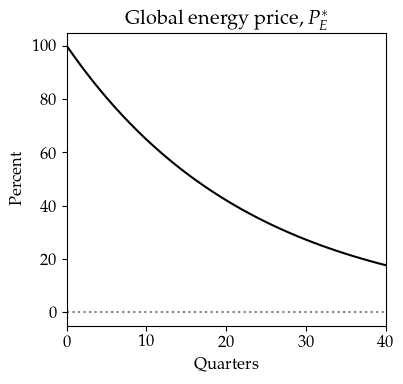

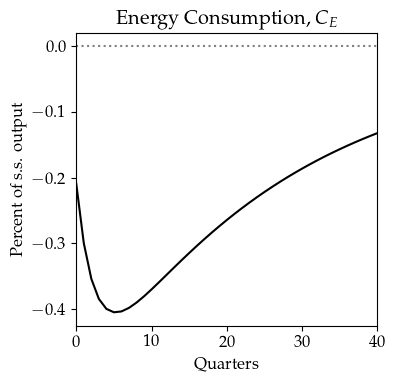

In [43]:
make_plot(ha_baseline_co, 
          panels=np.array([['PEstar']]), 
          titles=np.array([['Global energy price, $P_{E}^{*}$']]), 
          ylabels=['Percent'], 
          Tplot=41,
          legend_counter=0,
          filename='energy_PEstar')
 
make_plot(ha_baseline_co, 
          panels=np.array([['cE']]), 
          titles=np.array([['Energy Consumption, $C_{E}$']]), 
          ylabels=['Percent of s.s. output'], 
          Tplot=41,
          legend_counter=0,
          filename='energy_CEshock')

In [44]:
shocks = {'PEstar_shock': (shock_size*rho**np.arange(T)),'E_supply_shock': ha_baseline_co['E_supply_shock']}

# Plots

In [45]:
Tplot = 20

# Analytic results

### Benchmark RA and HA Output and Consumption, for various $\chi$

Setting thetaE and thetaF to zero!

RA plot


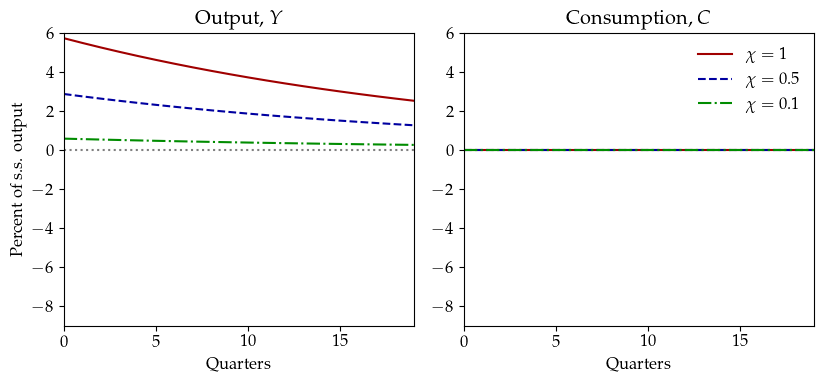

RA IM plot


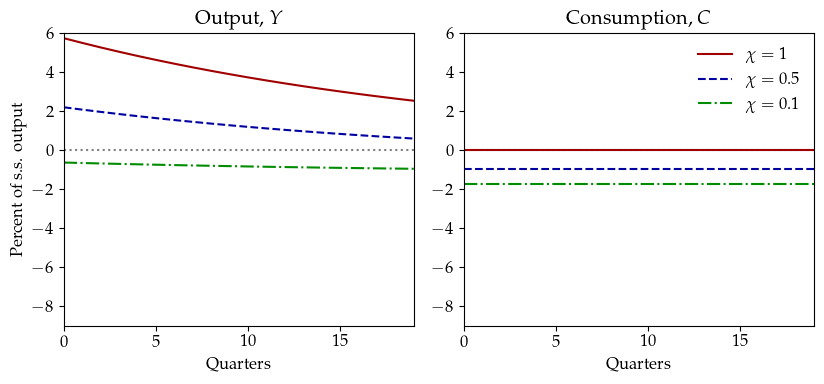

HA plot


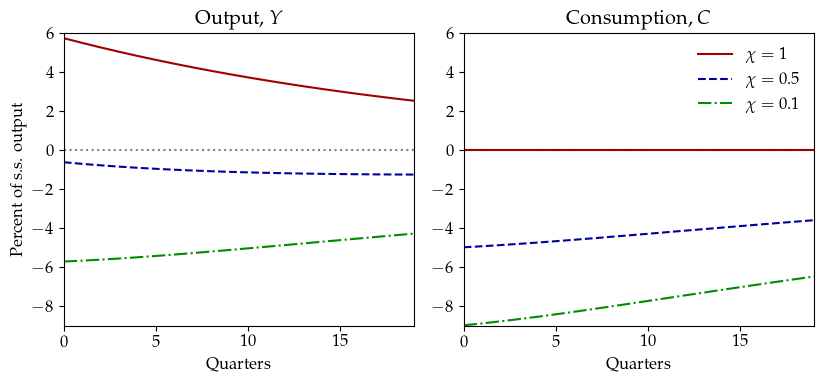

TA plot


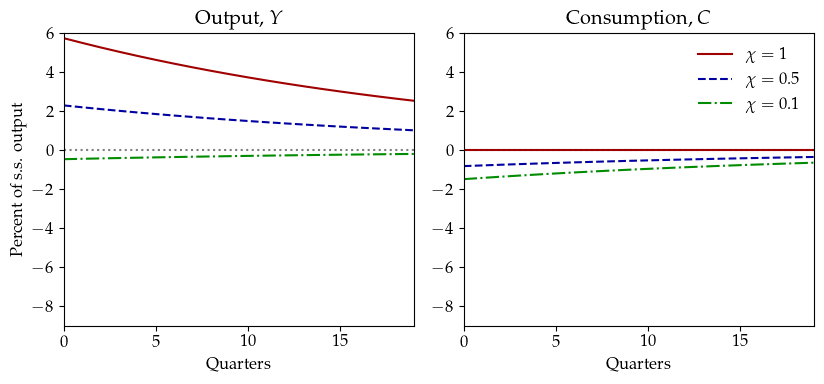

In [46]:
chitilde_list = [1, 0.5, 0.1]

ra_list = []
ra_im_list = []
ha_list = []
ta_list = []
for chitilde in chitilde_list:
    calib_here = dict(eta_E=chitilde, gamma=chitilde, eta=chitilde)
    ra = recalib(shocks, 'ra', **calib_here, analytic=True, resolve_ss=True)
    ra_im = recalib(shocks, 'ra_im', **calib_here, analytic=True, resolve_ss=True)
    ha = recalib(shocks, 'ha', **calib_here, analytic=True, resolve_ss=True)
    ta = recalib(shocks, 'ta', **calib_here, analytic=True, resolve_ss=True)
    ra_list.append(ra)
    ra_im_list.append(ra_im)
    ha_list.append(ha)
    ta_list.append(ta)

opt = dict(panels=np.array([['y', 'C']]), 
           Tplot=Tplot, 
           labels=[f'$\\chi = {chitilde}$' for chitilde in chitilde_list], 
           titles=np.array([['Output, $Y$', 'Consumption, $C$']]), 
           ylabels=['Percent of s.s. output',''], 
           legend_counter=2, 
           ylims=[[-9,6]]*2)

print('RA plot')
make_plot(ra_list, **opt, filename='energy_ra_yc')
print('RA IM plot')
make_plot(ra_im_list, **opt, filename='energy_raim_yc')
print('HA plot')
make_plot(ha_list, **opt, filename='energy_ha_yc')
print('TA plot')
make_plot(ta_list, **opt, filename='energy_ta_yc')

In [47]:
# Analytic check

analytical_1 = calibration['alpha_E']/(1-calibration['alpha_E']-calibration['alpha_F_tilde'])*ra_list[0]['PEstar_shock']
assert np.allclose(ra_list[0]['y'], analytical_1, atol=1e-4)
assert np.allclose(ha_list[0]['y'], analytical_1, atol=1e-4)
assert np.allclose(ra_im_list[0]['y'], analytical_1, atol=1e-4)
assert np.allclose(ra_list[1]['y'], 0.5*analytical_1, atol=1e-4)
assert np.allclose(ra_list[2]['y'], 0.1*analytical_1, atol=1e-4)

### RA-IM vs HA for different persistences

In [48]:
chitilde = 0.3
T_here = 600
calib_here = dict(eta_E=chitilde, gamma=chitilde, eta=chitilde)

rho_list = np.flip(1 - np.geomspace(1-0.99,1-0.6,10))
ra_im_list = np.zeros((len(rho_list)))
ha_list = np.zeros((len(rho_list)))

for i in range(len(rho_list)):
    rho_here = rho_list[i]
    shocks_here = {'PEstar_shock': (shock_size*rho_here**np.arange(T_here))}
    
    ra_im = recalib(shocks_here, 'ra_im', **calib_here, analytic=True, resolve_ss=True)
    ra_im_list[i] = ra_im['y'][0] * 100
    
    ha = recalib(shocks_here, 'ha', **calib_here, analytic=True, resolve_ss=True)
    ha_list[i] = ha['y'][0] * 100


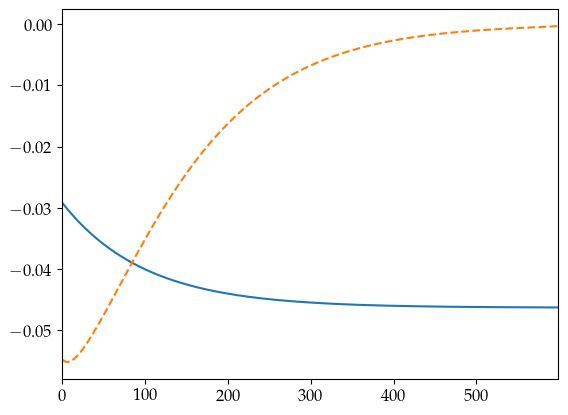

In [49]:
# Check the highest rho converges before the truncation

fig, ax = plt.subplots()
ax.plot(ra_im['y'])
ax.plot(ha['y'],'--')
plt.show()

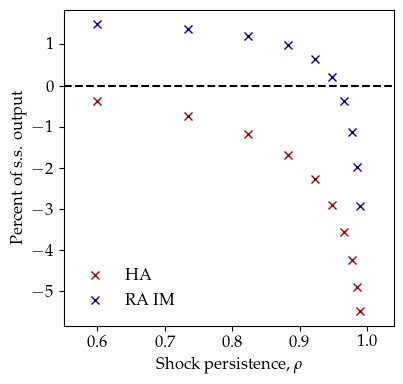

In [50]:
fig, ax = plt.subplots(figsize=(4.2,4))
ax.plot(rho_list,ha_list,linestyle='',marker='x',label='HA',color=redslide)
ax.plot(rho_list,ra_im_list,linestyle='',marker='x', label='RA IM',color=blueslide)
ax.hlines(0,min(rho_list)-0.05,max(rho_list)+0.05,linestyle='--',color='black')
ax.set_xlim(rho_list[0]-0.05,rho_list[-1]+0.05)
ax.set_xlabel('Shock persistence, $\\rho$')
ax.set_ylabel('Percent of s.s. output')
ax.legend()
plt.legend(framealpha=0)
plt.tight_layout()
# plt.savefig(f'Graphs/Figures/temp/' + 'energy_raim_ha_impact' + '.pdf', format='pdf', transparent=True)
plt.show()

### RA with production

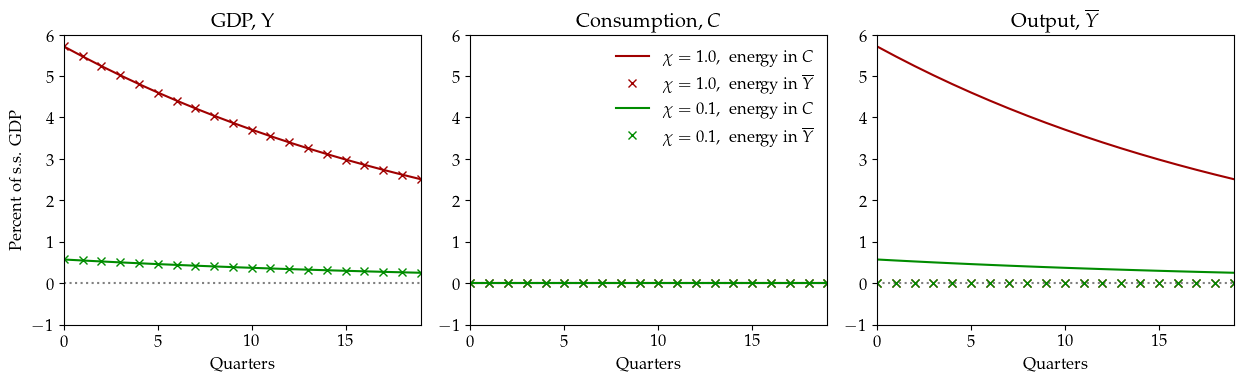

In [51]:
prodE_share = ss_ra['alpha_E'] / (1 - (1-ss_ra['alpha_E'])*ss_ra['alpha_F'])

ss_list = []
ra_prod_irfs = {}
for chitilde in [1.0, 0.1]:
    for prodE_share, alpha_E, alpha_F in [[0,ss_ra['alpha_E'],ss_ra['alpha_F']],[prodE_share,0,(1-ss_ra['alpha_E'])*ss_ra['alpha_F']]]:
        ra, ss = recalib(shocks, 'ra', analytic=True, 
                     eta_E=chitilde, gamma=chitilde, eta=chitilde, 
                     prodE_es=chitilde, 
                     prodE_share=prodE_share, 
                     alpha_F=alpha_F,
                     alpha_E = alpha_E,
                     alphastar = alpha_E + (1-alpha_E)*alpha_F + prodE_share/(1-prodE_share), 
                     resolve_ss=True, return_ss = True) 
        if prodE_share == 0:
            prodE_share_name = '$C$'
        else:
            prodE_share_name = '$\\overline{Y}$'
        ra_prod_irfs.update({f'$\\chi = {chitilde}, \:$ energy in {prodE_share_name}': ra})
        ss_list.append(ss)
        
opt = dict(Tplot=Tplot, linestyles=['-','']*2, colors=[redslide, redslide, greenslide, greenslide], ylabels=['Percent of s.s. GDP','','',''])
make_plot(list(ra_prod_irfs.values()), 
          labels=list(ra_prod_irfs.keys()) , 
          panels=np.array([['gdp', 'C', 'y']]),
          titles=np.array([['GDP, Y', 'Consumption, $C$', 'Output, $\overline{Y}$']]),
          markers=['','x']*2,
          legend_counter=2,
          ylims=[[-1,6]]*3,
          **opt,
          filename='energy_ra_prod') 

### Wage spiral

Price level response without importer frictions


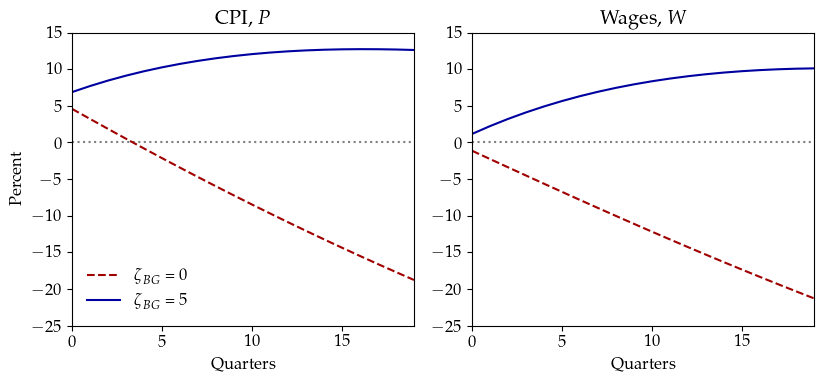

Inflation response without importer frictions


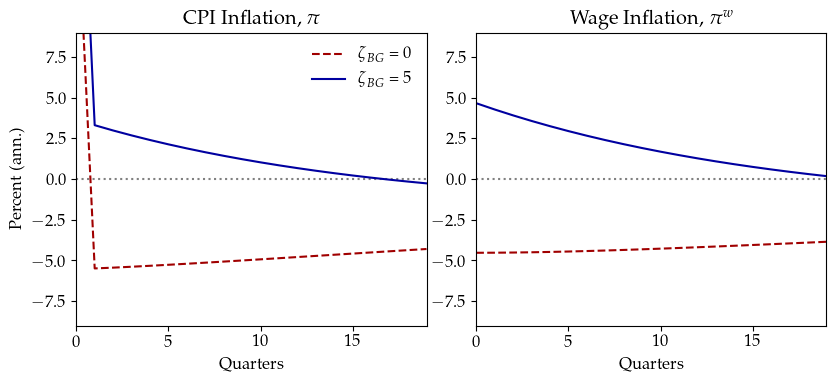

Inflation response with importer frictions


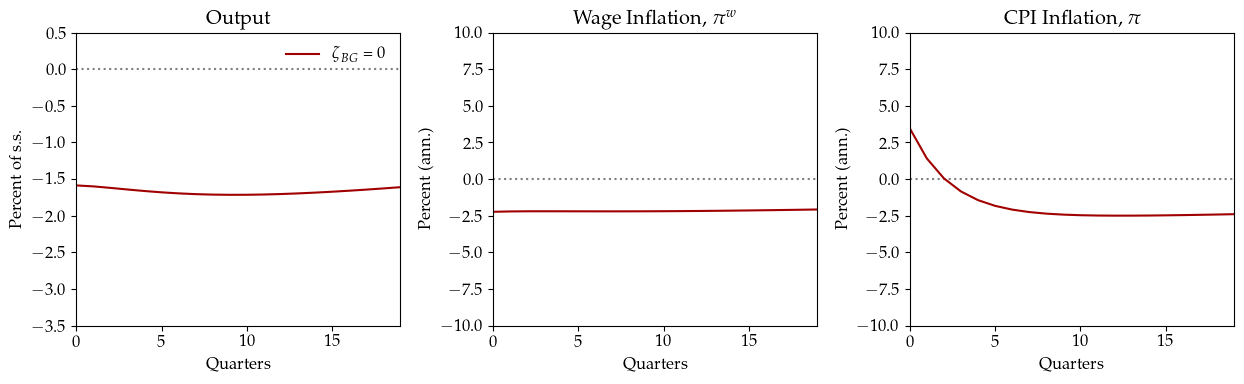

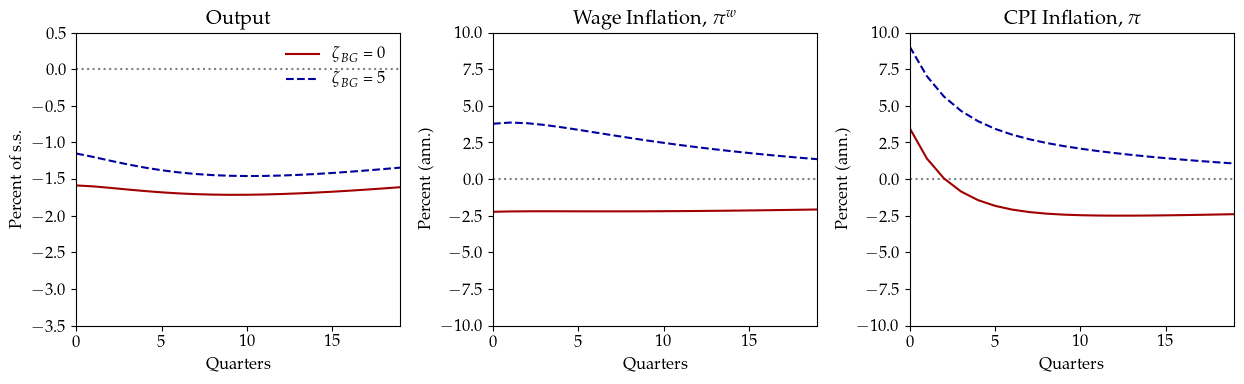

In [52]:
ha_list = []
for w_BG in [0,ss_ha['w_BG']]:
    ha = recalib(shocks, 'ha', w_BG=w_BG, analytic=True, resolve_ss=True) 
    ha_list.append(ha)
labels = ['$\\zeta_{BG}$ = 0', '$\\zeta_{BG}$ = 5']

print('Price level response without importer frictions')
opt = dict(Tplot=Tplot, labels=labels, ylabels=['Percent',''], linestyles = ['--', '-']) 
make_plot(ha_list, 
          panels=np.array([['P', 'W']]), 
          filename='energy_ha_ppw', 
          titles=np.array([['CPI, $P$', 'Wages, $W$']]), 
          **opt, ylims=[[-25,15]]*2, leg_loc='lower left')

print('Inflation response without importer frictions')
opt = dict(Tplot=Tplot, labels=labels, ylabels=['Percent (ann.)',''], linestyles = ['--', '-']) 
make_plot(ha_list, 
          panels=np.array([['pi_ann', 'piw_ann']]), 
          filename='energy_ha_pipiw', 
          titles=np.array([['CPI Inflation, $\\pi$', 'Wage Inflation, $\\pi^{w}$']]), 
          **opt, ylims=[[-9,9]]*2)

print('Inflation response with importer frictions')
ha_list = []
labels = []
for w_BG in [0,ss_ha['w_BG']]:
    ha_list.append(recalib(shocks, 'ha', w_BG=w_BG))
    labels.append('$\\zeta_{BG}$ = '+f'{w_BG}')
opt = dict(Tplot=Tplot, labels=labels, ylabels=['Percent of s.s.','Percent (ann.)','Percent (ann.)']) 

make_plot(ha_list[0], 
          panels=np.array([['y','piw_ann', 'pi_ann']]), 
          filename='energy_ha_pipiw_slides_withoutBG', 
          titles=np.array([['Output','Wage Inflation, $\\pi^{w}$','CPI Inflation, $\\pi$']]), 
          **opt | {'colors':[redslide]}, legend_counter=1, ylims=[[-3.5,0.5],[-10,10],[-10,10]])

make_plot(ha_list, 
          panels=np.array([['y','piw_ann', 'pi_ann']]), 
          filename='energy_ha_pipiw_slides', 
          titles=np.array([['Output','Wage Inflation, $\\pi^{w}$','CPI Inflation, $\\pi$']]), 
          **opt, legend_counter=1, ylims=[[-3.5,0.5],[-10,10],[-10,10]])

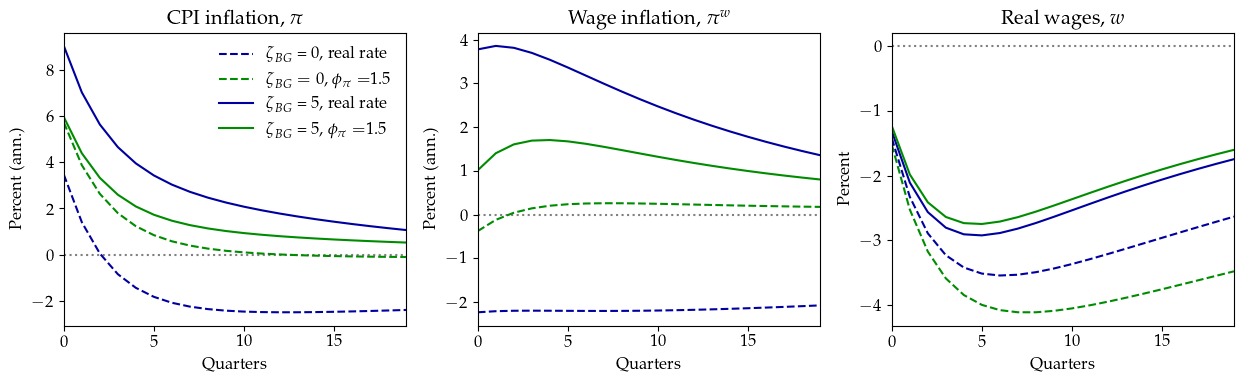

In [53]:
phi_pi = 1.5

ha_list = []
for w_BG in [0,5]:
    for rr in [1,0]:
        ha = recalib(shocks, 'ha', w_BG=w_BG, phi_pie=rr, phi_pi=(1-rr)*phi_pi) 
        ha_list.append(ha)
labels = ['$\\zeta_{BG}$ = 0, real rate', '$\\zeta_{BG} = 0$, $\\phi_{\\pi} = $'+str(phi_pi), '$\\zeta_{BG}$ = 5, real rate', '$\\zeta_{BG}$ = 5, $\\phi_{\\pi} = $'+str(phi_pi)]
 
opt = dict(Tplot=Tplot, labels=labels, ylabels=['Percent (ann.)','Percent (ann.)','Percent'], linestyles = ['--', '--','-','-'], colors=[blueslide,greenslide]*2) 
make_plot(ha_list, 
          panels=np.array([['pi_ann', 'piw_ann', 'w']]), 
          titles=np.array([['CPI inflation, $\\pi$', 'Wage inflation, $\\pi^{w}$','Real wages, $w$']]), 
          **opt, filename='energy_ha_pipiw_nominal')

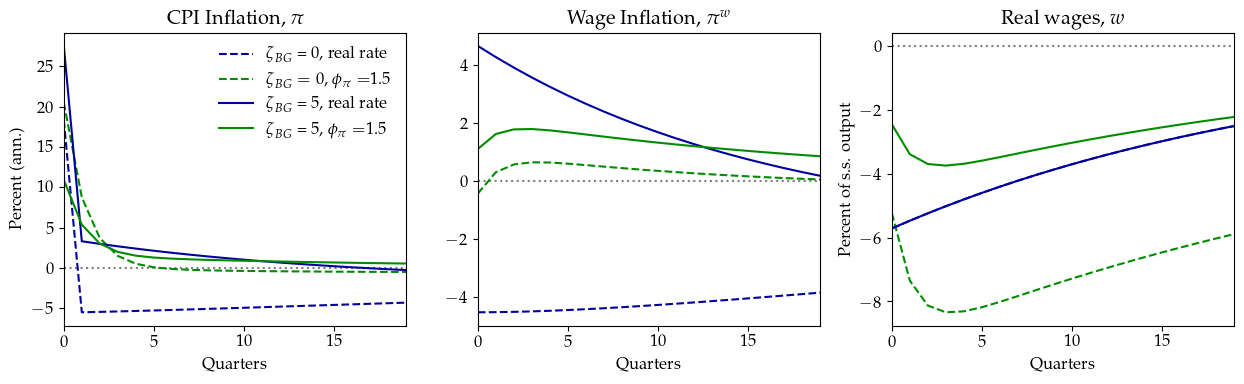

In [54]:
phi_pi = 1.5

ha_list = []
for w_BG in [0,5]:
    for rr in [1,0]:
        ha = recalib(shocks, 'ha', w_BG=w_BG, phi_pie=rr, phi_pi=(1-rr)*phi_pi, analytic=True, resolve_ss=True) 
        ha_list.append(ha)
labels = ['$\\zeta_{BG}$ = 0, real rate', '$\\zeta_{BG} = 0$, $\\phi_{\\pi} = $'+str(phi_pi), '$\\zeta_{BG}$ = 5, real rate', '$\\zeta_{BG}$ = 5, $\\phi_{\\pi} = $'+str(phi_pi)]
 
opt = dict(Tplot=Tplot, labels=labels, ylabels=['Percent (ann.)','','Percent of s.s. output','Percent'], linestyles = ['--', '--','-','-'], colors=[blueslide,greenslide]*2) 
make_plot(ha_list, 
          panels=np.array([['pi_ann', 'piw_ann', 'w']]), 
          titles=np.array([['CPI Inflation, $\\pi$', 'Wage Inflation, $\\pi^{w}$','Real wages, $w$']]), 
          **opt, filename='energy_ha_pipiw_nominal_noimporter')
for l in ['labels','colors','linestyles','ylabels']:
    opt.pop(l)

### Flex price equilibrium

Choose real rate to set wage inflation to zero.

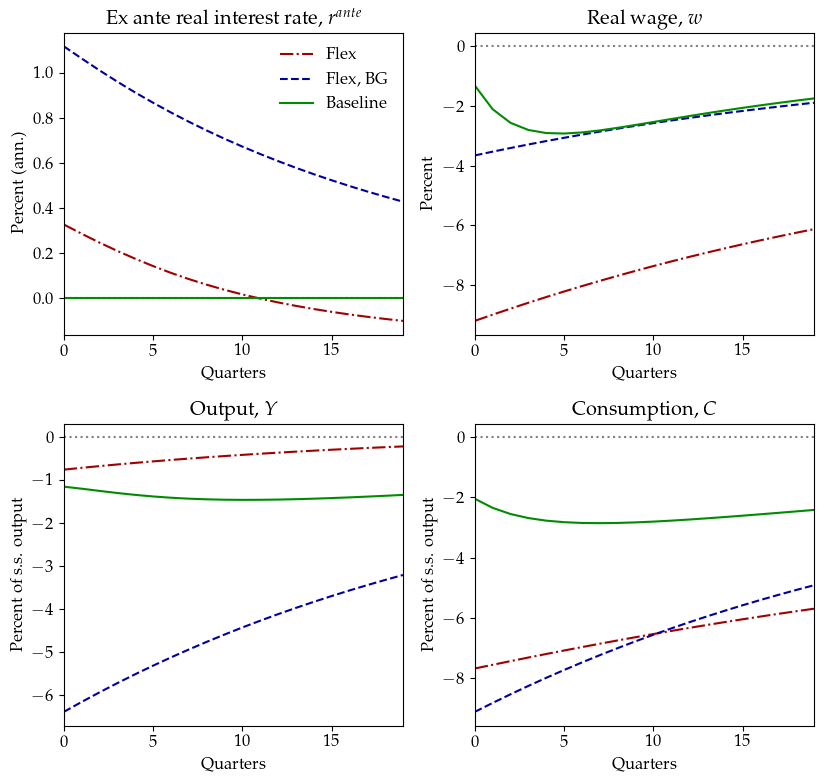

In [55]:
ha_neutral = recalib(shocks, 'ha')

ha_flex = recalib(shocks, 
                  unknowns_td_ = unknowns_td | {'ishock'}, 
                  targets_td_ = targets_td | {'piw'}, 
                  w_BG=0, analytic=True, resolve_ss=True)

ha_flex_BG = recalib(shocks, 
                  unknowns_td_ = unknowns_td | {'ishock'}, 
                  targets_td_ = targets_td | {'piw'}, 
                  analytic=True, resolve_ss=True)

make_plot([ha_flex,ha_flex_BG,ha_neutral], 
          panels=np.array([['rante_ann', 'w'],['y', 'C']]), 
          titles=np.array([['Ex ante real interest rate, $r^{ante}$', 'Real wage, $w$'], ['Output, $Y$', 'Consumption, $C$']]),
          labels=['Flex', 'Flex, BG', 'Baseline'], 
          ylabels=['Percent (ann.)','Percent','Percent of s.s. output','Percent of s.s. output'],
          Tplot=Tplot, filename='energy_ha_flex',
          #colors=[redslide,greenslide,blueslide],
          linestyles=['dashdot','--','-'])

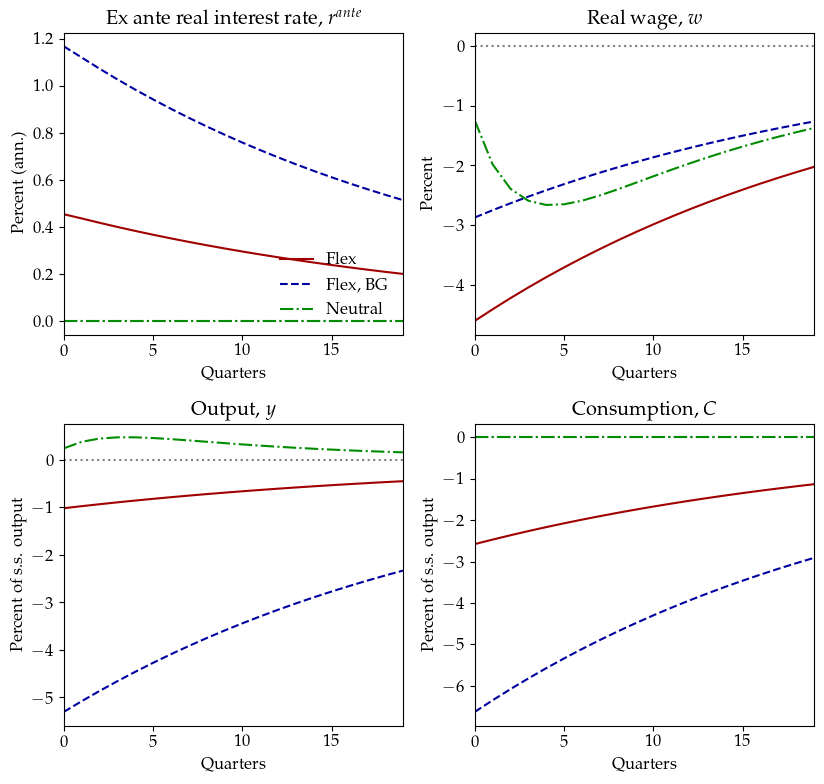

In [56]:
ra_neutral = recalib(shocks, 'ra')

ra_flex = recalib(shocks, 'ra',
                  unknowns_td_ = unknowns_td | {'ishock'}, 
                  targets_td_ = targets_td | {'piw'}, 
                  w_BG=0, analytic=True, resolve_ss=True)

ra_flex_BG = recalib(shocks, 'ra',
                  unknowns_td_ = unknowns_td | {'ishock'}, 
                  targets_td_ = targets_td | {'piw'}, 
                  analytic=True, resolve_ss=True)

make_plot([ra_flex,ra_flex_BG,ra_neutral], 
          panels=np.array([['rante_ann', 'w'],['y', 'C']]), 
          titles=np.array([['Ex ante real interest rate, $r^{ante}$', 'Real wage, $w$'], ['Output, $y$', 'Consumption, $C$']]),
          labels=['Flex', 'Flex, BG', 'Neutral'], 
          ylabels=['Percent (ann.)','Percent','Percent of s.s. output','Percent of s.s. output'],
          Tplot=Tplot, leg_loc='lower right', filename='energy_ra_flex')

## Energy endowment

In [57]:
zetaEsupply_list = [0,0.5,1]
chi_list = [0.5,0.2,0.1]

ha_list = {}
for chitilde in chi_list:
    ha_list[f'$\chi$={chitilde}'] = {}

for i in range(len(zetaEsupply_list)):
    zetaEsupply = zetaEsupply_list[i]
    for chitilde in chi_list:
        markup_original = ss_ha['markup_ss'] / (1-ss_ha['zetaEsupply']*ss_ha['alpha_E'])
        ha_endow, ss_endow = recalib(shocks, 
                           **{'zetaEsupply':zetaEsupply,
                              'y': 1-zetaEsupply*ss_ha['alpha_E'],
                              'markup_ss': markup_original * (1-zetaEsupply*ss_ha['alpha_E']),
                              'alphastar': ss_ha['alpha'] - ss_ha['alpha_E']*zetaEsupply,
                              'Z': markup_original * (1-zetaEsupply*ss_ha['alpha_E'])}, 
                           **dict(eta_E=chitilde, gamma=chitilde, eta=chitilde),
                           analytic=True,
                           resolve_ss=True, return_ss=True)
        ha_list[f'$\chi$={chitilde}'][f'share={zetaEsupply}'] = ha_endow['y']

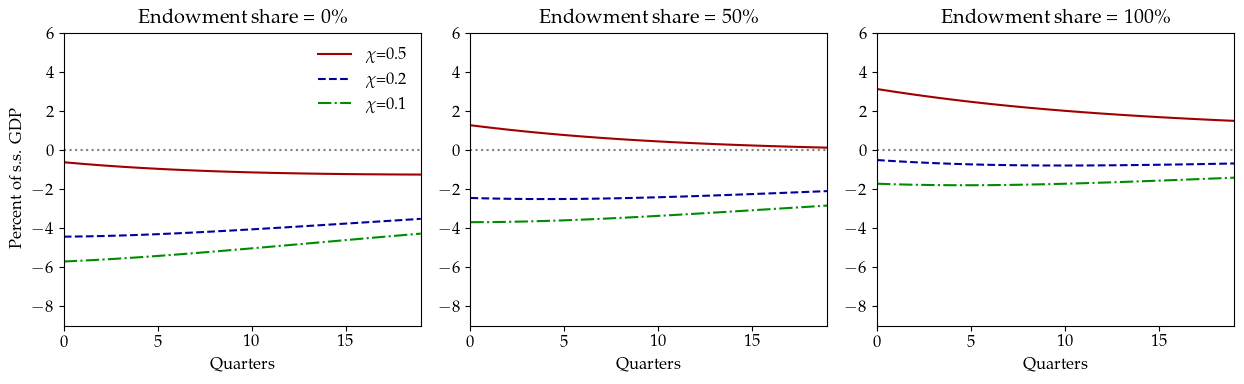

In [58]:
make_plot(list(ha_list.values()), 
          labels = list(ha_list.keys()),
          panels=np.array([[f'share={z}' for z in zetaEsupply_list]]),
          titles=np.array([[f'Endowment share = {int(100*z)}\%' for z in zetaEsupply_list]]), 
          **opt, ylims=[[-9,6]]*3, ylabels=['Percent of s.s. GDP','',''],
          filename='energy_endowment')

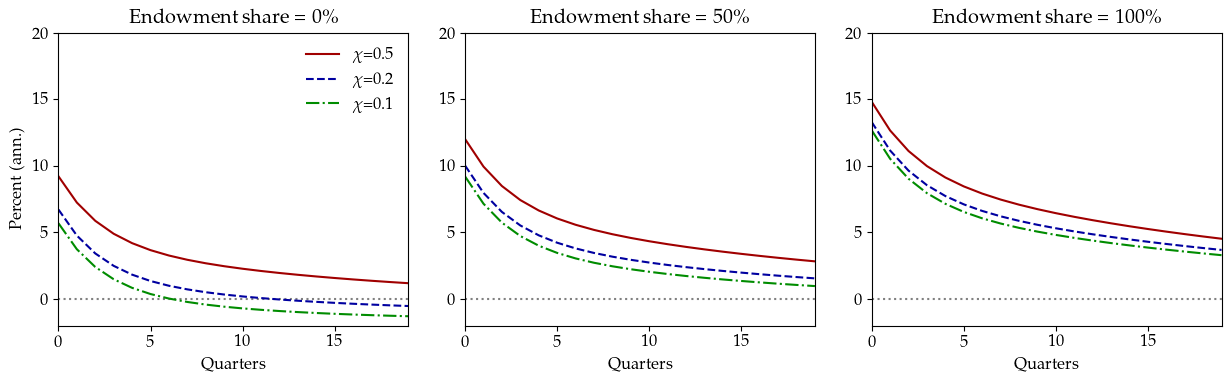

In [59]:
zetaEsupply_list = [0,0.5,1]
chi_list = [0.5,0.2,0.1]

ha_list = {}
for chitilde in chi_list:
    ha_list[f'$\chi$={chitilde}'] = {}

for i in range(len(zetaEsupply_list)):
    zetaEsupply = zetaEsupply_list[i]
    for chitilde in chi_list:
        ha_endow, ss_endow = recalib(shocks, 
                           **{'zetaEsupply':zetaEsupply,
                              'y': 1-zetaEsupply*ss_ha['alpha_E'],
                              'markup_ss': ss_ha['markup_ss'] * (1-zetaEsupply*ss_ha['alpha_E']),
                              'alphastar': ss_ha['alpha'] - ss_ha['alpha_E']*zetaEsupply,
                              'Z': ss_ha['markup_ss'] * (1-zetaEsupply*ss_ha['alpha_E'])}, 
                           **dict(eta_E=chitilde, gamma=chitilde, eta=chitilde),
                           analytic=True, **{'theta_E':ss_ha['theta_E'],'theta_F':ss_ha['theta_F']}, # re-introduce importer frictions for inflation plot
                           resolve_ss=True, return_ss=True)
        ha_list[f'$\chi$={chitilde}'][f'share={zetaEsupply}'] = ha_endow['pi_ann']

make_plot(list(ha_list.values()), 
          labels = list(ha_list.keys()),
          panels=np.array([[f'share={z}' for z in zetaEsupply_list]]),
          titles=np.array([[f'Endowment share = {int(100*z)}\%' for z in zetaEsupply_list]]), 
          **opt, ylims=[[-2,20]]*3, ylabels=['Percent (ann.)','',''],
          filename='energy_endowment_prices')

# Quantitative model results

## Monetary Policy (real rate shocks)

In [60]:
# Real rate shock
rshock_dev = 0.01/4 * 2 * 0.85**np.arange(T)

# Common MP calibration
calib_opt = {}

# Plot options
opt = dict(Tplot=Tplot, colors=[blueslide, redslide, greenslide], ylims={'pi_ann':[-0.5,13], 'y':[-6,2], 'C':[-6,2]})

In [61]:
ha_mon_real_list = {}
ha_mon_real_list['neutral'] = recalib(shocks, **calib_opt)

shocks_real_tight = dict(**shocks, ishock=ha_mon_real_list['neutral']['rante'] + rshock_dev)
shocks_real_easy = dict(**shocks, ishock=ha_mon_real_list['neutral']['rante'] - rshock_dev)

ha_mon_real_list['tight'] = recalib(shocks_real_tight, **calib_opt)
ha_mon_real_list['easy'] = recalib(shocks_real_easy, **calib_opt)

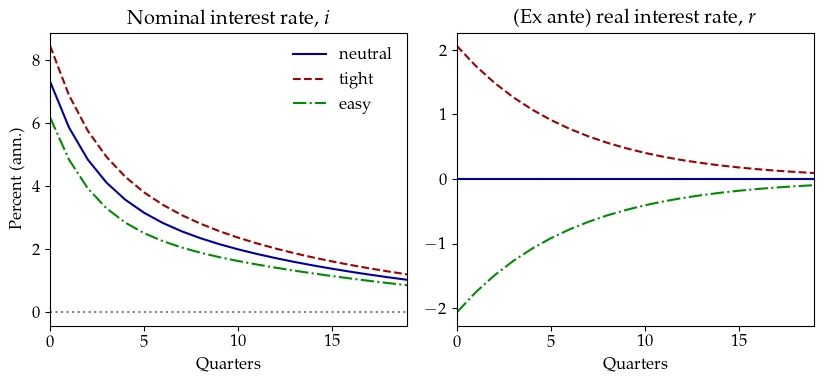

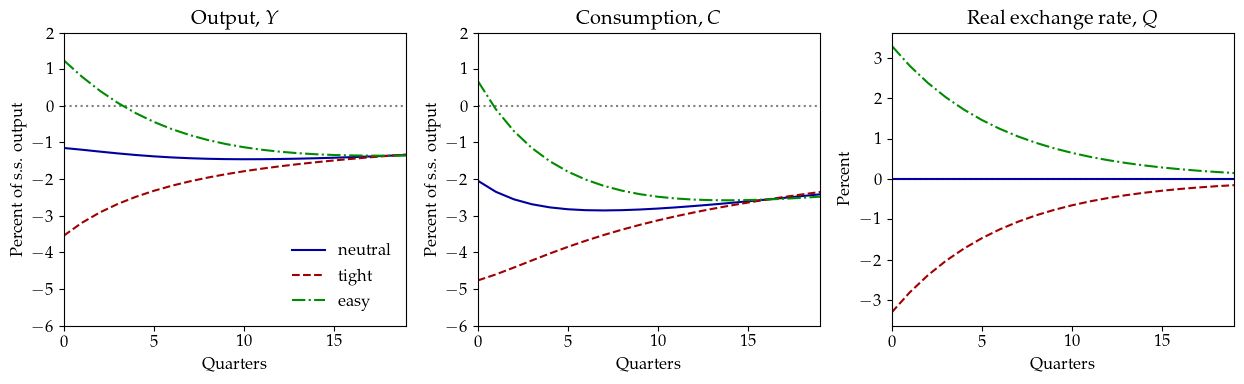

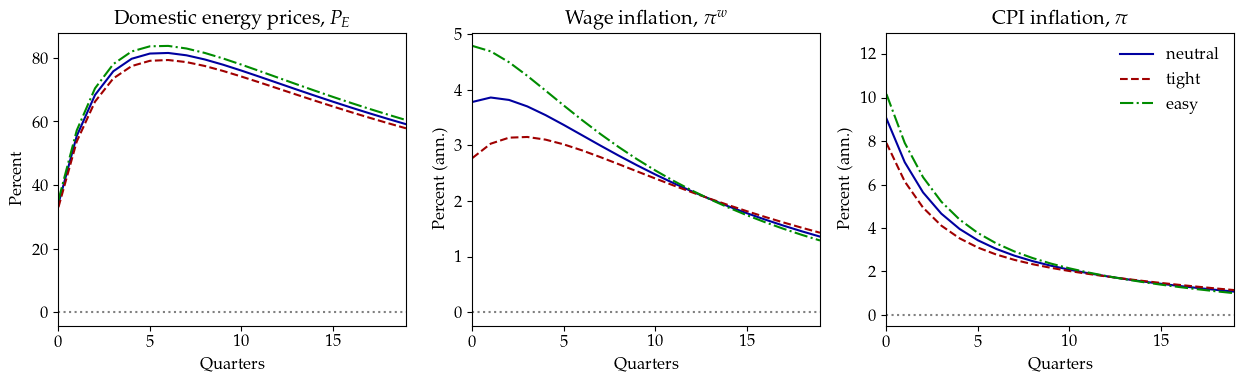

In [62]:
irfs_list = list(ha_mon_real_list.values())

make_plot(irfs_list,
          labels = list(ha_mon_real_list.keys()),
          panels=np.array([['inom_ann', 'rante_ann']]), 
          titles=np.array([['Nominal interest rate, $i$', '(Ex ante) real interest rate, $r$']]), 
          ylabels=['Percent (ann.)', ''],
          filename='energy_mp_real_i', 
          **opt)

make_plot(irfs_list, 
          labels = list(ha_mon_real_list.keys()),
          panels=np.array([['y', 'C', 'Q']]), 
          titles=np.array([['Output, $Y$', 'Consumption, $C$', 'Real exchange rate, $Q$']]),
          ylabels=['Percent of s.s. output','Percent of s.s. output','Percent'], 
          **opt, leg_loc='lower right',
          filename='energy_mp_cy_real_slides') 

make_plot(irfs_list, 
          labels = list(ha_mon_real_list.keys()),
          panels=np.array([['PE', 'piw_ann', 'pi_ann']]), 
          titles=np.array([['Domestic energy prices, $P_{E}$', 'Wage inflation, $\\pi^{w}$', 'CPI inflation, $\\pi$']]),
          ylabels=['Percent','Percent (ann.)','Percent (ann.)'], 
          **opt, legend_counter=3,
          filename='energy_mp_prices_real_slides') 

In [63]:
contraction = ha_mon_real_list['neutral']['y'][0] * 100
contraction

-1.1505974879053524

In [64]:
peak_piw = np.max(ha_mon_real_list['neutral']['piw_ann'] * 100)
peak_piw

3.8579276000305365

### Coordination

In [65]:
shocks_real_tight = dict(**E_shock, ishock=ha_mon_real_list['neutral']['rante'] + rshock_dev)
shocks_real_easy = dict(**E_shock, ishock=ha_mon_real_list['neutral']['rante'] - rshock_dev)

In [66]:
calib_opt_E = dict(**calib_opt, E_supply_elasticity=0)

ha_mon_real_co_list = {}
ha_mon_real_co_list['neutral'] = recalib(E_shock, **calib_opt_E)  
ha_mon_real_co_list['tight'] = recalib(shocks_real_tight, **calib_opt_E) 
ha_mon_real_co_list['easy'] = recalib(shocks_real_easy, **calib_opt_E) 

In [67]:
# Percent increased effect of MP on impact
diff = ha_mon_real_list['tight']['pi_ann'][0]-ha_mon_real_list['neutral']['pi_ann'][0]
diff_co = ha_mon_real_co_list['tight']['pi_ann'][0]-ha_mon_real_co_list['neutral']['pi_ann'][0]
coordination = diff_co / diff

In [68]:
100*(ha_mon_real_co_list['tight']['pi_ann'][0] - ha_mon_real_list['tight']['pi_ann'][0])

-1.8545657787324052

#### Non cooperation

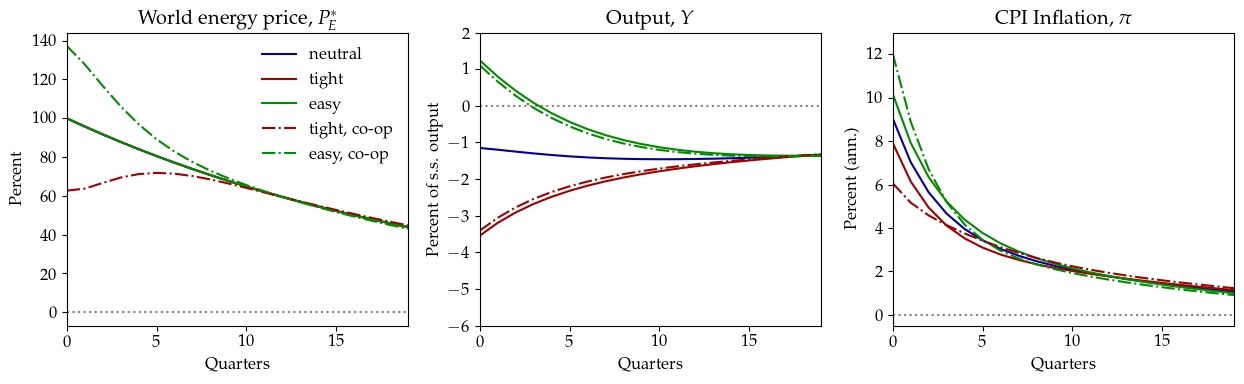

In [69]:
irfs = ha_mon_real_list | {k+', co-op': ha_mon_real_co_list[k] for k in ['tight','easy']}
opt_here = opt | dict(colors=[blueslide, redslide, greenslide, redslide, greenslide], 
                      linestyles=['-','-','-','dashdot','dashdot'],
                      markers=[None]*6)

make_plot(list(irfs.values()), 
          labels=list(irfs.keys()), 
          panels=np.array([['PEstar', 'y', 'pi_ann']]), 
          titles=np.array([['World energy price, $P_{E}^{*}$', 'Output, $Y$', 'CPI Inflation, $\\pi$']]),
          ylabels=['Percent','Percent of s.s. output','Percent (ann.)'],
          filename='energy_mp_real_co_noco',
          **opt_here) 

## Monetary policy and nonlinearity

### Downward nominal wage rigidity

In [70]:
calib_opt = dict()

ha_neutral = recalib(shocks, 'ha', **calib_opt)

ha_noinf = recalib(shocks, 
                   unknowns_td_ = unknowns_td | {'ishock'}, 
                   targets_td_ = targets_td | {'P'},
                   **calib_opt)

ha_noinf_dnwr = recalib(shocks, 
                   unknowns_td_ = unknowns_td | {'ishock'}, 
                   targets_td_ = targets_td | {'P'},
                   **calib_opt, theta_w=1)

#### Plots

In [71]:
def diff_dict(d1,d2):
    keys1 = list(d1.keys())
    keys2 = list(d2.keys())
    common_keys = list(set(keys1).intersection(keys2))
    d = {}
    for k in common_keys:
        d[k] = d1[k] - d2[k]
    for k in list(set(keys1) - set(common_keys)):
        print(k + ' is only in first dict.')
    for k in list(set(keys2) - set(common_keys)):
        print(k + ' is only in second dict.')
    return d

Marginal output drop required to counteract the inflation path when DNWR does and doesnt bite:
- todo: more formal version with KT constraints.

ishock is only in first dict.
ishock is only in first dict.


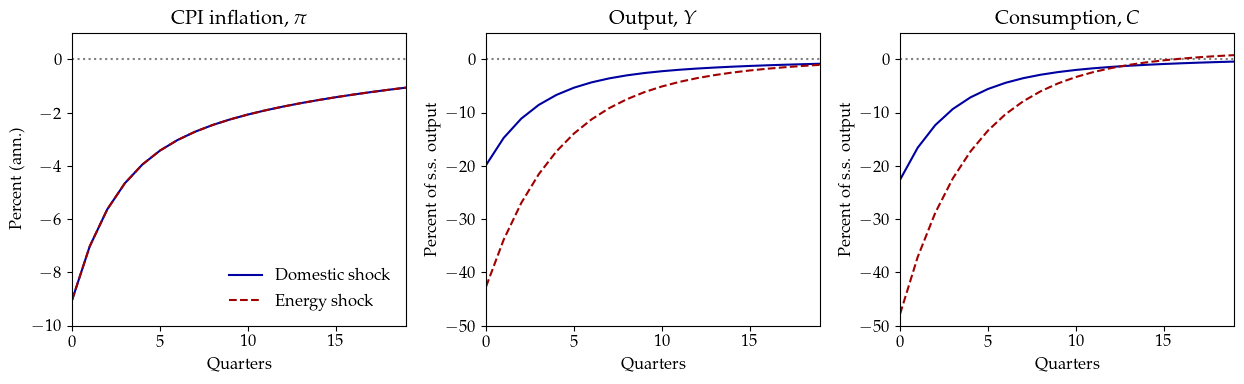

In [72]:
ha_noinf_diff = diff_dict(ha_noinf,ha_neutral)
ha_noinf_dnwr_diff = diff_dict(ha_noinf_dnwr,ha_neutral)

make_plot([ha_noinf_diff,ha_noinf_dnwr_diff], 
          panels=np.array([['pi_ann', 'y','C']]), 
          titles=np.array([['CPI inflation, $\\pi$','Output, $Y$', 'Consumption, $C$']]), 
          labels=['Domestic shock','Energy shock'], 
          ylabels=['Percent (ann.)','Percent of s.s. output','Percent of s.s. output'],
          colors=[blueslide, redslide, greenslide],
          leg_loc='lower right', legend_counter=1,
          Tplot=Tplot,
          filename='energy_mp_domestic',
          ylims={'y':[-50,5],'C':[-50,5], 'pi_ann':[-10,1]})

### Nonlinear MIT shock

In [73]:
@sj.simple
def hh_outputs_nl(C, atw_n, pH_PHF, pEhh_P, pF_PHF, pHF_P, cH, cF, cE, eta, eta_E, alpha_E, alpha_F, markup_ss, cbarE, scale_w):
    alpha_F_tilde = (1-alpha_E)*alpha_F
    cH_t = (1-alpha_E - alpha_F_tilde) * (pH_PHF)**(-eta) * pHF_P**(-eta_E) * C - cH
    cF_t = alpha_F_tilde * (pF_PHF)**(-eta) * pHF_P**(-eta_E) * C - cF
    cE_t = cbarE*(atw_n*markup_ss)*scale_w + cbarE*(1-scale_w) + alpha_E * pEhh_P**(-eta_E) * C - cE
    return cH_t, cF_t, cE_t

@sj.solved(unknowns={'piF':0.,'PF':1.}, targets=['piF_res','PFres'], solver="broyden_custom")
def foreignPrices_nl(piF,PF,P,Q,PFstar,rante,theta_F,cF):
    PFres = (1+piF) * PF(-1) - PF
    pF_P = PF / P
    beta_F = 1/(1+rante.ss)
    kappa_F = (1 - theta_F) * (1 - beta_F * theta_F) / theta_F
    piF_term = Q * PFstar / pF_P - 1
    piF_res = kappa_F * (cF/cF.ss) * piF_term + beta_F * piF(1) * (1+piF(1)) - piF * (1+piF) 
    return piF_res, PFres, pF_P

@sj.solved(unknowns={'piE':(-0.5,0.,1.),'PE':(0.1,1.,5.)}, targets=['piE_res','PEres'], solver="broyden_custom")
def energyPrices_nl(piE,PE,P,Q,PEstar,rante,theta_E,tauE,cE):
    PEres = (1+piE) * PE(-1) - PE
    pE_P = PE / P
    beta_E = 1/(1+rante.ss)
    kappa_E = (1 - theta_E) * (1 - beta_E * theta_E) / theta_E
    piE_term = Q * PEstar / pE_P - 1
    piE_res = kappa_E * (cE/cE.ss) * piE_term + beta_E * piE(1) * (1+piE(1)) - piE * (1+piE)
    
    pE_P_ss = pE_P.ss # Looks like you cant use PE.ss inside a het input(?)
    pEhh_P = (1-tauE) * pE_P + tauE * pE_P.ss
    pEhh = pEhh_P * P
    return piE_res, PEres, pE_P, pE_P_ss, pEhh_P, pEhh

importPrices_nl = sj.combine([foreignPrices_nl,energyPrices_nl])

model_nl = sj.combine([hh_ha, hh_outputs_nl, foreign_c, revaluation, mon_policy, fiscal, income, importPrices_nl, importProfits, profitcenters, UIP, eqm_cond, CA,
                       unions, CESprices, price_levels, piW_to_W, pitop, revaluation_dom, annualize, IEA])

Nonlinear model with importers

In [74]:
ss_nl = ss_ha.copy()
ss_nl.update({'cH_t':0,'cF_t':0,'cE_t':0})

irf_nl = model_nl.solve_impulse_nonlinear(ss_nl, 
                                 unknowns_td | {'cH','cF','cE'}, 
                                 targets_td | {'cH_t','cF_t','cE_t'}, 
                                 shocks, 
                                 options=dict(energyPrices_nl={'maxit':100}))
test_targets(irf_nl)

Solving pitop_to_hh_outputs_nl_combined for ['w', 'cE', 'r', 'tauY', 'cH', 'pi', 'PEstar', 'cF', 'y'] to hit ['cH_t', 'goods_clearing', 'pires', 'cE_t', 'cF_t', 'E_clearing', 'r_res', 'w_res', 'tauY_res']
Solving pitop_inner for ['P'] to hit ['Pres']
On iteration 0
   max error for Pres is 0.00E+00
Solving mon_policy_inner for ['inom'] to hit ['inom_res']
On iteration 0
   max error for inom_res is 0.00E+00
Solving UIP_inner for ['Q'] to hit ['uip']
On iteration 0
   max error for uip is 0.00E+00
Solving IEA_inner for ['J_Esupply'] to hit ['J_Esupply_res']
On iteration 0
   max error for J_Esupply_res is 4.03E-03
On iteration 1
   max error for J_Esupply_res is 1.33E-15
Solving energyPrices_nl_inner for ['piE', 'PE'] to hit ['piE_res', 'PEres']
On iteration 0
   max error for piE_res is 0.00E+00
   max error for PEres is 0.00E+00
Solving foreignPrices_nl_inner for ['piF', 'PF'] to hit ['piF_res', 'PFres']
On iteration 0
   max error for piF_res is 0.00E+00
   max error for PFres is 0.0

Solving CA_inner for ['nfa'] to hit ['nfares']
On iteration 0
   max error for nfares is 2.75E-01
On iteration 1
   max error for nfares is 7.19E-17
Solving unions_inner for ['piw'] to hit ['piwres']
On iteration 0
   max error for piwres is 8.40E-04
On iteration 1
   max error for piwres is 1.12E-05
On iteration 2
   max error for piwres is 2.67E-07
On iteration 3
   max error for piwres is 6.08E-09
Solving piW_to_W_inner for ['W'] to hit ['Wres']
On iteration 0
   max error for Wres is 9.73E-03
On iteration 1
   max error for Wres is 5.40E-04
On iteration 2
   max error for Wres is 2.77E-05
On iteration 3
   max error for Wres is 1.08E-06
On iteration 4
   max error for Wres is 3.32E-08
On iteration 5
   max error for Wres is 8.19E-10
On iteration 1
   max error for cH_t is 1.02E-03
   max error for goods_clearing is 1.04E-03
   max error for pires is 6.96E-03
   max error for cE_t is 9.85E-04
   max error for cF_t is 5.71E-04
   max error for E_clearing is 0.00E+00
   max error for 

Solving CA_inner for ['nfa'] to hit ['nfares']
On iteration 0
   max error for nfares is 2.48E-01
On iteration 1
   max error for nfares is 1.64E-17
Solving unions_inner for ['piw'] to hit ['piwres']
On iteration 0
   max error for piwres is 7.62E-04
On iteration 1
   max error for piwres is 9.36E-06
On iteration 2
   max error for piwres is 2.06E-07
On iteration 3
   max error for piwres is 4.31E-09
Solving piW_to_W_inner for ['W'] to hit ['Wres']
On iteration 0
   max error for Wres is 9.03E-03
On iteration 1
   max error for Wres is 5.17E-04
On iteration 2
   max error for Wres is 2.63E-05
On iteration 3
   max error for Wres is 1.03E-06
On iteration 4
   max error for Wres is 3.14E-08
On iteration 5
   max error for Wres is 7.73E-10
On iteration 2
   max error for cH_t is 8.22E-05
   max error for goods_clearing is 5.06E-05
   max error for pires is 8.81E-04
   max error for cE_t is 2.25E-05
   max error for cF_t is 3.29E-05
   max error for E_clearing is 0.00E+00
   max error for 

Solving CA_inner for ['nfa'] to hit ['nfares']
On iteration 0
   max error for nfares is 2.49E-01
On iteration 1
   max error for nfares is 3.91E-17
Solving unions_inner for ['piw'] to hit ['piwres']
On iteration 0
   max error for piwres is 7.77E-04
On iteration 1
   max error for piwres is 9.63E-06
On iteration 2
   max error for piwres is 2.16E-07
On iteration 3
   max error for piwres is 4.55E-09
Solving piW_to_W_inner for ['W'] to hit ['Wres']
On iteration 0
   max error for Wres is 9.12E-03
On iteration 1
   max error for Wres is 5.18E-04
On iteration 2
   max error for Wres is 2.62E-05
On iteration 3
   max error for Wres is 1.02E-06
On iteration 4
   max error for Wres is 3.08E-08
On iteration 5
   max error for Wres is 7.55E-10
On iteration 3
   max error for cH_t is 2.06E-05
   max error for goods_clearing is 1.59E-06
   max error for pires is 4.67E-04
   max error for cE_t is 2.12E-06
   max error for cF_t is 8.42E-06
   max error for E_clearing is 0.00E+00
   max error for 

Solving CA_inner for ['nfa'] to hit ['nfares']
On iteration 0
   max error for nfares is 2.48E-01
On iteration 1
   max error for nfares is 3.91E-17
Solving unions_inner for ['piw'] to hit ['piwres']
On iteration 0
   max error for piwres is 7.75E-04
On iteration 1
   max error for piwres is 9.60E-06
On iteration 2
   max error for piwres is 2.14E-07
On iteration 3
   max error for piwres is 4.52E-09
Solving piW_to_W_inner for ['W'] to hit ['Wres']
On iteration 0
   max error for Wres is 9.11E-03
On iteration 1
   max error for Wres is 5.18E-04
On iteration 2
   max error for Wres is 2.62E-05
On iteration 3
   max error for Wres is 1.02E-06
On iteration 4
   max error for Wres is 3.08E-08
On iteration 5
   max error for Wres is 7.53E-10
On iteration 4
   max error for cH_t is 3.56E-06
   max error for goods_clearing is 1.59E-07
   max error for pires is 1.68E-04
   max error for cE_t is 3.59E-07
   max error for cF_t is 1.45E-06
   max error for E_clearing is 0.00E+00
   max error for 

...

Solving CA_inner for ['nfa'] to hit ['nfares']
On iteration 0
   max error for nfares is 2.48E-01
On iteration 1
   max error for nfares is 3.91E-17
Solving unions_inner for ['piw'] to hit ['piwres']
On iteration 0
   max error for piwres is 7.74E-04
On iteration 1
   max error for piwres is 9.58E-06
On iteration 2
   max error for piwres is 2.14E-07
On iteration 3
   max error for piwres is 4.51E-09
Solving piW_to_W_inner for ['W'] to hit ['Wres']
On iteration 0
   max error for Wres is 9.11E-03
On iteration 1
   max error for Wres is 5.17E-04
On iteration 2
   max error for Wres is 2.62E-05
On iteration 3
   max error for Wres is 1.01E-06
On iteration 4
   max error for Wres is 3.07E-08
On iteration 5
   max error for Wres is 7.52E-10
On iteration 9
   max error for cH_t is 1.44E-08
   max error for goods_clearing is 2.07E-09
   max error for pires is 4.03E-07
   max error for cE_t is 4.37E-09
   max error for cF_t is 1.06E-08
   max error for E_clearing is 0.00E+00
   max error for 

Solving CA_inner for ['nfa'] to hit ['nfares']
On iteration 0
   max error for nfares is 2.48E-01
On iteration 1
   max error for nfares is 1.64E-17
Solving unions_inner for ['piw'] to hit ['piwres']
On iteration 0
   max error for piwres is 7.74E-04
On iteration 1
   max error for piwres is 9.58E-06
On iteration 2
   max error for piwres is 2.14E-07
On iteration 3
   max error for piwres is 4.51E-09
Solving piW_to_W_inner for ['W'] to hit ['Wres']
On iteration 0
   max error for Wres is 9.11E-03
On iteration 1
   max error for Wres is 5.17E-04
On iteration 2
   max error for Wres is 2.62E-05
On iteration 3
   max error for Wres is 1.01E-06
On iteration 4
   max error for Wres is 3.07E-08
On iteration 5
   max error for Wres is 7.52E-10
On iteration 10
   max error for cH_t is 6.65E-09
   max error for goods_clearing is 1.20E-09
   max error for pires is 5.97E-07
   max error for cE_t is 2.22E-09
   max error for cF_t is 5.77E-09
   max error for E_clearing is 0.00E+00
   max error for

Solving CA_inner for ['nfa'] to hit ['nfares']
On iteration 0
   max error for nfares is 2.48E-01
On iteration 1
   max error for nfares is 1.50E-16
Solving unions_inner for ['piw'] to hit ['piwres']
On iteration 0
   max error for piwres is 7.74E-04
On iteration 1
   max error for piwres is 9.58E-06
On iteration 2
   max error for piwres is 2.14E-07
On iteration 3
   max error for piwres is 4.51E-09
Solving piW_to_W_inner for ['W'] to hit ['Wres']
On iteration 0
   max error for Wres is 9.11E-03
On iteration 1
   max error for Wres is 5.17E-04
On iteration 2
   max error for Wres is 2.62E-05
On iteration 3
   max error for Wres is 1.01E-06
On iteration 4
   max error for Wres is 3.07E-08
On iteration 5
   max error for Wres is 7.52E-10
On iteration 11
   max error for cH_t is 1.60E-09
   max error for goods_clearing is 2.12E-10
   max error for pires is 1.58E-08
   max error for cE_t is 4.70E-10
   max error for cF_t is 1.11E-09
   max error for E_clearing is 0.00E+00
   max error for

Solving CA_inner for ['nfa'] to hit ['nfares']
On iteration 0
   max error for nfares is 2.48E-01
On iteration 1
   max error for nfares is 1.64E-17
Solving unions_inner for ['piw'] to hit ['piwres']
On iteration 0
   max error for piwres is 7.74E-04
On iteration 1
   max error for piwres is 9.58E-06
On iteration 2
   max error for piwres is 2.14E-07
On iteration 3
   max error for piwres is 4.51E-09
Solving piW_to_W_inner for ['W'] to hit ['Wres']
On iteration 0
   max error for Wres is 9.11E-03
On iteration 1
   max error for Wres is 5.17E-04
On iteration 2
   max error for Wres is 2.62E-05
On iteration 3
   max error for Wres is 1.01E-06
On iteration 4
   max error for Wres is 3.07E-08
On iteration 5
   max error for Wres is 7.52E-10
On iteration 12
   max error for cH_t is 1.06E-09
   max error for goods_clearing is 1.87E-10
   max error for pires is 8.66E-08
   max error for cE_t is 3.50E-10
   max error for cF_t is 9.03E-10
   max error for E_clearing is 0.00E+00
   max error for

Solving CA_inner for ['nfa'] to hit ['nfares']
On iteration 0
   max error for nfares is 2.48E-01
On iteration 1
   max error for nfares is 9.47E-17
Solving unions_inner for ['piw'] to hit ['piwres']
On iteration 0
   max error for piwres is 7.74E-04
On iteration 1
   max error for piwres is 9.58E-06
On iteration 2
   max error for piwres is 2.14E-07
On iteration 3
   max error for piwres is 4.51E-09
Solving piW_to_W_inner for ['W'] to hit ['Wres']
On iteration 0
   max error for Wres is 9.11E-03
On iteration 1
   max error for Wres is 5.17E-04
On iteration 2
   max error for Wres is 2.62E-05
On iteration 3
   max error for Wres is 1.01E-06
On iteration 4
   max error for Wres is 3.07E-08
On iteration 5
   max error for Wres is 7.52E-10
On iteration 13
   max error for cH_t is 1.55E-10
   max error for goods_clearing is 1.92E-11
   max error for pires is 4.48E-09
   max error for cE_t is 4.30E-11
   max error for cF_t is 9.69E-11
   max error for E_clearing is 0.00E+00
   max error for

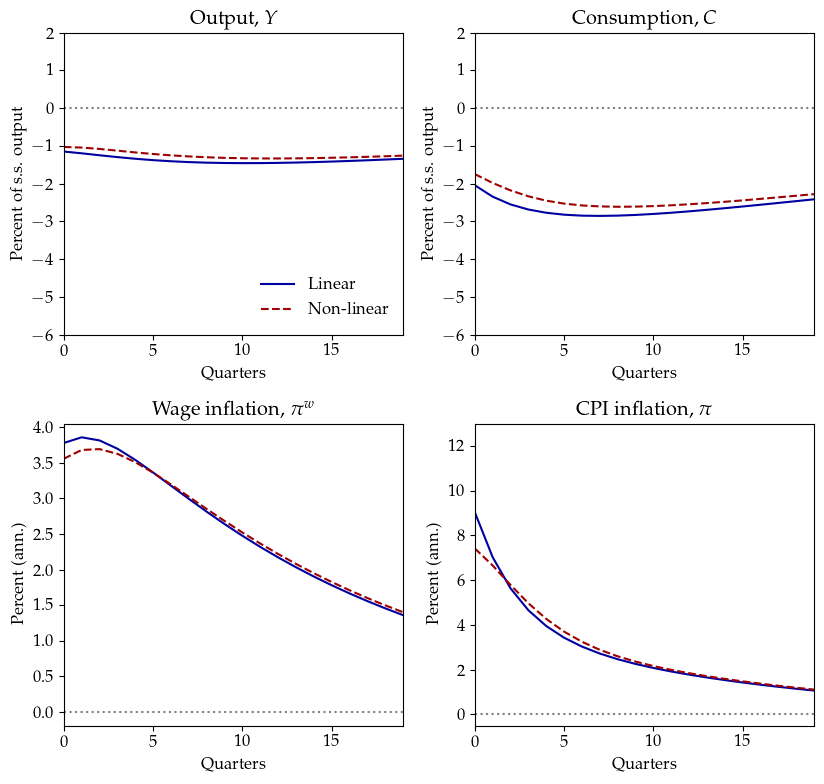

In [75]:
irfs_list = [ha_mon_real_list['neutral'],irf_nl]

make_plot(irfs_list, 
          labels = ['Linear','Non-linear'],
          panels=np.array([['y', 'C'], ['piw_ann', 'pi_ann']]), 
          titles=np.array([['Output, $Y$', 'Consumption, $C$'],['Wage inflation, $\\pi^{w}$', 'CPI inflation, $\\pi$']]),
          ylabels=['Percent of s.s. output','Percent of s.s. output', 'Percent (ann.)','Percent (ann.)'], 
          **opt, leg_loc='lower right',
          filename='energy_nonlinear') 

Nonlinear model without importers

In this case, the piF_term needs to be zero, so the cF term doesnt matter. Nevertheless, seems to struggle nonlinearly when setting theta very small, so set up special block.

In [76]:
@sj.simple
def foreignPrices_nl(P,Q,PFstar,rante,theta_F):
    PF = Q * PFstar * P
    pF_P = PF / P
    piF = PF / PF(-1) - 1 
    return pF_P, PF, piF

@sj.simple
def energyPrices_nl(P,Q,PEstar,rante,theta_E,tauE):
    PE = Q * PEstar * P
    pE_P = PE / P
    piE = PE / PE(-1) - 1
    pE_P_ss = pE_P.ss # Looks like you cant use PE.ss inside a het input(?)
    pEhh_P = (1-tauE) * pE_P + tauE * pE_P.ss
    pEhh = pEhh_P * P
    return piE, PE, pE_P, pE_P_ss, pEhh_P, pEhh

importPrices_nl = sj.combine([foreignPrices_nl,energyPrices_nl])

model_nl = sj.combine([hh_ha, hh_outputs, foreign_c, revaluation, mon_policy, fiscal, income, importPrices_nl, importProfits, profitcenters, UIP, eqm_cond, CA,
                       unions, CESprices, price_levels, piW_to_W, pitop, revaluation_dom, annualize, IEA])

In [77]:
# maxit was 60, temporarily here to try endow 25% with original theta_w
irf_nl = model_nl.solve_impulse_nonlinear(ss_ha, unknowns_td, targets_td, 
                                          shocks, options=dict(pitop_to_revaluation_combined={'maxit':500})) 
test_targets(irf_nl)

ha_noimporter = recalib(shocks, 'ha', theta_F = 0.0001, theta_E = 0.0001) 

Solving pitop_to_revaluation_combined for ['w', 'r', 'tauY', 'PEstar', 'pi', 'y'] to hit ['E_clearing', 'goods_clearing', 'w_res', 'r_res', 'pires', 'tauY_res']
Solving pitop_inner for ['P'] to hit ['Pres']
On iteration 0
   max error for Pres is 0.00E+00
Solving mon_policy_inner for ['inom'] to hit ['inom_res']
On iteration 0
   max error for inom_res is 0.00E+00
Solving UIP_inner for ['Q'] to hit ['uip']
On iteration 0
   max error for uip is 0.00E+00
Solving IEA_inner for ['J_Esupply'] to hit ['J_Esupply_res']
On iteration 0
   max error for J_Esupply_res is 4.03E-03
On iteration 1
   max error for J_Esupply_res is 1.33E-15
Solving CESprices_inner for ['pHF_P', 'pH_PHF'] to hit ['inner_nest', 'outer_nest']
On iteration 0
   max error for inner_nest is 0.00E+00
   max error for outer_nest is 0.00E+00
Solving income_inner for ['J', 'j'] to hit ['Jres', 'jres']
On iteration 0
   max error for Jres is 0.00E+00
   max error for jres is 0.00E+00
Solving unions_inner for ['piw'] to hit ['p

Solving unions_inner for ['piw'] to hit ['piwres']
On iteration 0
   max error for piwres is 1.69E-03
On iteration 1
   max error for piwres is 4.21E-05
On iteration 2
   max error for piwres is 1.81E-06
On iteration 3
   max error for piwres is 7.15E-08
On iteration 4
   max error for piwres is 2.71E-09
Solving piW_to_W_inner for ['W'] to hit ['Wres']
On iteration 0
   max error for Wres is 1.61E-02
On iteration 1
   max error for Wres is 1.05E-03
On iteration 2
   max error for Wres is 7.05E-05
On iteration 3
   max error for Wres is 3.52E-06
On iteration 4
   max error for Wres is 1.35E-07
On iteration 5
   max error for Wres is 4.12E-09
Solving fiscal_inner for ['B'] to hit ['B_res']
On iteration 0
   max error for B_res is 0.00E+00
Solving importProfits_inner for ['JF', 'JE'] to hit ['JF_res', 'JE_res']
On iteration 0
   max error for JF_res is 0.00E+00
   max error for JE_res is 8.01E-18
Solving CA_inner for ['nfa'] to hit ['nfares']
On iteration 0
   max error for nfares is 1.03

Solving unions_inner for ['piw'] to hit ['piwres']
On iteration 0
   max error for piwres is 1.68E-03
On iteration 1
   max error for piwres is 4.18E-05
On iteration 2
   max error for piwres is 1.79E-06
On iteration 3
   max error for piwres is 7.05E-08
On iteration 4
   max error for piwres is 2.66E-09
Solving piW_to_W_inner for ['W'] to hit ['Wres']
On iteration 0
   max error for Wres is 1.61E-02
On iteration 1
   max error for Wres is 1.04E-03
On iteration 2
   max error for Wres is 6.96E-05
On iteration 3
   max error for Wres is 3.46E-06
On iteration 4
   max error for Wres is 1.32E-07
On iteration 5
   max error for Wres is 3.99E-09
Solving fiscal_inner for ['B'] to hit ['B_res']
On iteration 0
   max error for B_res is 0.00E+00
Solving importProfits_inner for ['JF', 'JE'] to hit ['JF_res', 'JE_res']
On iteration 0
   max error for JF_res is 0.00E+00
   max error for JE_res is 8.00E-18
Solving CA_inner for ['nfa'] to hit ['nfares']
On iteration 0
   max error for nfares is 1.03

Solving income_inner for ['J', 'j'] to hit ['Jres', 'jres']
On iteration 0
   max error for Jres is 1.14E-03
   max error for jres is 0.00E+00
On iteration 1
   max error for Jres is 2.22E-16
   max error for jres is 2.22E-16
Solving unions_inner for ['piw'] to hit ['piwres']
On iteration 0
   max error for piwres is 1.69E-03
On iteration 1
   max error for piwres is 4.19E-05
On iteration 2
   max error for piwres is 1.79E-06
On iteration 3
   max error for piwres is 7.08E-08
On iteration 4
   max error for piwres is 2.67E-09
Solving piW_to_W_inner for ['W'] to hit ['Wres']
On iteration 0
   max error for Wres is 1.61E-02
On iteration 1
   max error for Wres is 1.04E-03
On iteration 2
   max error for Wres is 6.96E-05
On iteration 3
   max error for Wres is 3.46E-06
On iteration 4
   max error for Wres is 1.32E-07
On iteration 5
   max error for Wres is 3.99E-09
Solving fiscal_inner for ['B'] to hit ['B_res']
On iteration 0
   max error for B_res is 0.00E+00
Solving importProfits_inner

On iteration 1
   max error for inner_nest is 7.05E-05
   max error for outer_nest is 1.45E-04
On iteration 2
   max error for inner_nest is 2.89E-07
   max error for outer_nest is 1.72E-06
On iteration 3
   max error for inner_nest is 1.18E-09
   max error for outer_nest is 1.60E-08
On iteration 4
   max error for inner_nest is 4.84E-12
   max error for outer_nest is 1.35E-10
Solving income_inner for ['J', 'j'] to hit ['Jres', 'jres']
On iteration 0
   max error for Jres is 1.14E-03
   max error for jres is 4.44E-16
On iteration 1
   max error for Jres is 2.22E-16
   max error for jres is 2.22E-16
Solving unions_inner for ['piw'] to hit ['piwres']
On iteration 0
   max error for piwres is 1.69E-03
On iteration 1
   max error for piwres is 4.19E-05
On iteration 2
   max error for piwres is 1.79E-06
On iteration 3
   max error for piwres is 7.08E-08
On iteration 4
   max error for piwres is 2.67E-09
Solving piW_to_W_inner for ['W'] to hit ['Wres']
On iteration 0
   max error for Wres is

On iteration 1
   max error for J_Esupply_res is 8.88E-16
Solving CESprices_inner for ['pHF_P', 'pH_PHF'] to hit ['inner_nest', 'outer_nest']
On iteration 0
   max error for inner_nest is 3.46E-02
   max error for outer_nest is 0.00E+00
On iteration 1
   max error for inner_nest is 7.05E-05
   max error for outer_nest is 1.45E-04
On iteration 2
   max error for inner_nest is 2.89E-07
   max error for outer_nest is 1.72E-06
On iteration 3
   max error for inner_nest is 1.18E-09
   max error for outer_nest is 1.60E-08
On iteration 4
   max error for inner_nest is 4.84E-12
   max error for outer_nest is 1.35E-10
Solving income_inner for ['J', 'j'] to hit ['Jres', 'jres']
On iteration 0
   max error for Jres is 1.14E-03
   max error for jres is 0.00E+00
On iteration 1
   max error for Jres is 2.22E-16
   max error for jres is 2.22E-16
Solving unions_inner for ['piw'] to hit ['piwres']
On iteration 0
   max error for piwres is 1.69E-03
On iteration 1
   max error for piwres is 4.19E-05
On i

On iteration 0
   max error for inner_nest is 3.46E-02
   max error for outer_nest is 0.00E+00
On iteration 1
   max error for inner_nest is 7.05E-05
   max error for outer_nest is 1.45E-04
On iteration 2
   max error for inner_nest is 2.89E-07
   max error for outer_nest is 1.72E-06
On iteration 3
   max error for inner_nest is 1.18E-09
   max error for outer_nest is 1.60E-08
On iteration 4
   max error for inner_nest is 4.84E-12
   max error for outer_nest is 1.35E-10
Solving income_inner for ['J', 'j'] to hit ['Jres', 'jres']
On iteration 0
   max error for Jres is 1.14E-03
   max error for jres is 0.00E+00
On iteration 1
   max error for Jres is 2.22E-16
   max error for jres is 2.22E-16
Solving unions_inner for ['piw'] to hit ['piwres']
On iteration 0
   max error for piwres is 1.69E-03
On iteration 1
   max error for piwres is 4.19E-05
On iteration 2
   max error for piwres is 1.79E-06
On iteration 3
   max error for piwres is 7.08E-08
On iteration 4
   max error for piwres is 2.

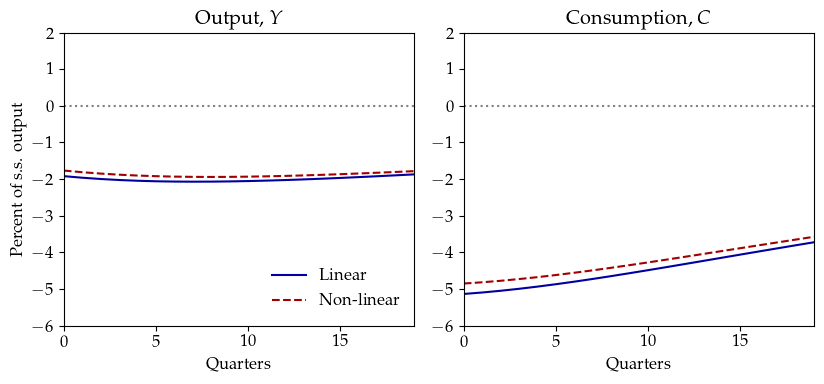

In [78]:
irfs_list = [ha_noimporter,irf_nl]

make_plot(irfs_list, 
          labels = ['Linear','Non-linear'],
          panels=np.array([['y', 'C']]), 
          titles=np.array([['Output, $Y$', 'Consumption, $C$']]),
          ylabels=['Percent of s.s. output',''], 
          **opt, leg_loc='lower right',
          filename='energy_nonlinear_noimporters') 

## State dependence

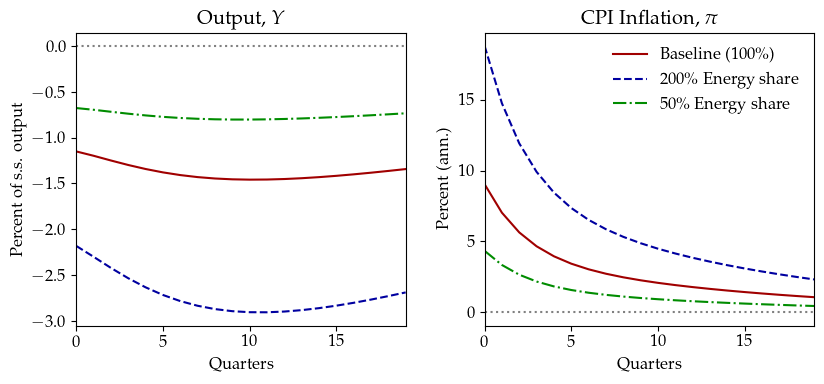

In [79]:
# When you have a non-zero zetaEsupply, you need to update y, markup_ss, alphastar, and Z when you adjust alpha_E

alpha_E_low = ss_ha['alpha_E'] / 2
markup_original = ss_ha['markup_ss'] / (1-ss_ha['zetaEsupply']*ss_ha['alpha_E'])
calib_low = dict(alpha_E = alpha_E_low,
                 alpha_F = (calibration['alpha']-alpha_E_low)/(1-alpha_E_low),
                 E_supply_shock = alpha_E_low,
                 y = 1-ss_ha['zetaEsupply']*alpha_E_low,
                 markup_ss = markup_original * (1-ss_ha['zetaEsupply']*alpha_E_low),
                 alphastar = ss_ha['alpha'] - alpha_E_low*ss_ha['zetaEsupply'],
                 Z = markup_original * (1-ss_ha['zetaEsupply']*alpha_E_low))

alpha_E_high = ss_ha['alpha_E'] * 2
calib_high = dict(alpha_E = alpha_E_high,
                  alpha_F = (calibration['alpha']-alpha_E_high)/(1-alpha_E_high),
                  E_supply_shock = alpha_E_high,
                 y = 1-ss_ha['zetaEsupply']*alpha_E_high,
                 markup_ss = markup_original * (1-ss_ha['zetaEsupply']*alpha_E_high),
                 alphastar = ss_ha['alpha'] - alpha_E_high*ss_ha['zetaEsupply'],
                 Z = markup_original * (1-ss_ha['zetaEsupply']*alpha_E_high))

ha_sd = {}
ha_sd['Baseline (100\%)'] = recalib(shocks, resolve_ss=True)
ha_sd['200\% Energy share'] = recalib(shocks, **calib_high, resolve_ss=True)
ha_sd['50\% Energy share'] = recalib(shocks, **calib_low, resolve_ss=True)

make_plot(list(ha_sd.values()), 
          labels = list(ha_sd.keys()),
          panels=np.array([['y', 'pi_ann']]),
          titles=np.array([['Output, $Y$', 'CPI Inflation, $\\pi$']]),
          ylabels=['Percent of s.s. output','Percent (ann.)'],
          Tplot=Tplot, legend_counter=2,
          filename='energy_state_dependence') 

In [80]:
shocks_here = {'PEstar_shock': recalib(dict(ishock=rshock_dev), **calib_opt_E, resolve_ss=True)['PEstar']}
shocks_here_high = {'PEstar_shock': recalib(dict(ishock=rshock_dev), **calib_opt_E|calib_high, resolve_ss=True)['PEstar']}
shocks_here_low = {'PEstar_shock': recalib(dict(ishock=rshock_dev), **calib_opt_E|calib_low, resolve_ss=True)['PEstar']}

ha_spill_sd = {}
ha_spill_sd['Baseline (100\%)'] = recalib(shocks_here, resolve_ss=True)
ha_spill_sd['200\% Energy share'] = recalib(shocks_here_high, **calib_high, resolve_ss=True)
ha_spill_sd['50\% Energy share'] = recalib(shocks_here_low, **calib_low, resolve_ss=True)

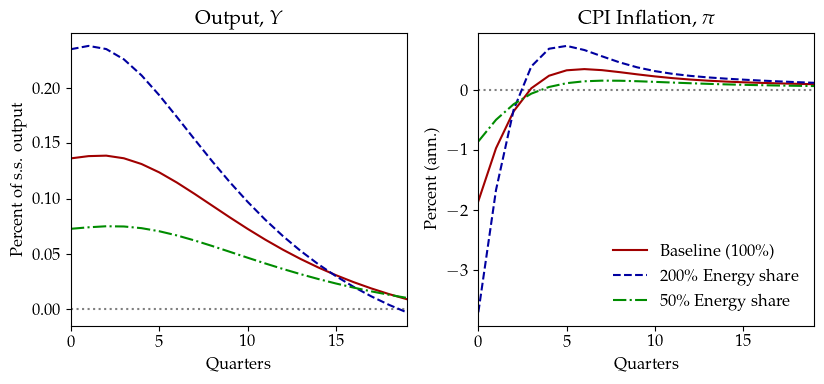

In [81]:
make_plot(list(ha_spill_sd.values()), 
          labels = list(ha_spill_sd.keys()),
          panels=np.array([['y', 'pi_ann']]),
          titles=np.array([['Output, $Y$', 'CPI Inflation, $\\pi$']]),
          ylabels=['Percent of s.s. output','Percent (ann.)'],
          legend_counter=2, leg_loc='lower right',
          Tplot=Tplot,
          filename='energy_spillover_state_dependence') 

## Energy vs Markup shock

In [82]:
taylor_rule_target = 'phi_pi'
matching = 'piw'

EM_calib = {} # 'theta_F': 0.0001, 'theta_E': 0.0001

E_vs_M = {}
E_vs_M['E, RR'] = recalib(shocks, **EM_calib)
E_vs_M['E, TR'] = recalib(shocks, **EM_calib|{'phi_pie':0,taylor_rule_target:1.5}) 

G_wedge = model_ha.solve_jacobian(ss_ha,unknowns_td,targets_td,inputs=['union_wedge'],T=100)
J_pi_wedge = G_wedge[matching]['union_wedge']
wedge = np.linalg.inv(J_pi_wedge) @ E_vs_M['E, RR'][matching]

markup_shock = {'union_wedge':wedge}
E_vs_M['M, RR'] = recalib(markup_shock, **EM_calib)
E_vs_M['M, TR'] = recalib(markup_shock, **EM_calib|{'phi_pie':0,taylor_rule_target:1.5})

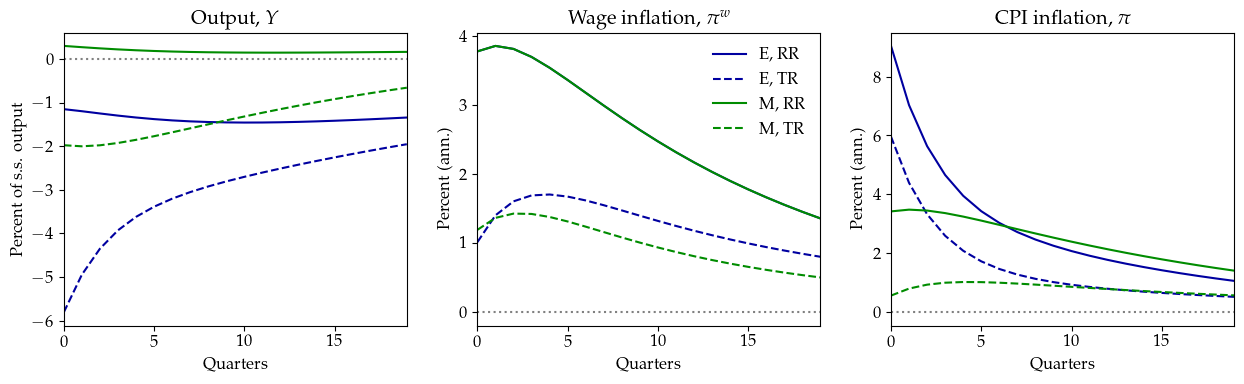

In [83]:
make_plot(list(E_vs_M.values()), 
          labels = list(E_vs_M.keys()),
          panels=np.array([['y','piw_ann','pi_ann']]),
          titles=np.array([['Output, $Y$', 'Wage inflation, $\pi^{w}$', 'CPI inflation, $\pi$']]),
          legend_counter=2,
          colors = [blueslide,blueslide,greenslide,greenslide],
          linestyles=['-','--','-','--'],
          Tplot=Tplot,
          ylabels=['Percent of s.s. output','Percent (ann.)','Percent (ann.)'], 
          filename='energy_markup'
         ) 

## Spillovers in different models

Compute the PEstar impulse that results from a coordinated tightening. Then, feed that shock in to a single country. That is the spillover to you of everyone else tightening. Then consider how this spillover varies with and without the BG rigidity, and in the RA and HA case.

In [84]:
shocks_here = {'PEstar_shock': recalib(dict(ishock=rshock_dev), **calib_opt_E)['PEstar']}

test = ha_mon_real_co_list['tight']['PEstar'] - ha_mon_real_co_list['neutral']['PEstar']
assert np.linalg.norm(test - shocks_here['PEstar_shock']) < 1e-10

ha_spill_list = {}
ha_spill_list['HA'] = recalib(shocks_here)
ha_spill_list['RA'] = recalib(shocks_here, modelname='ra')

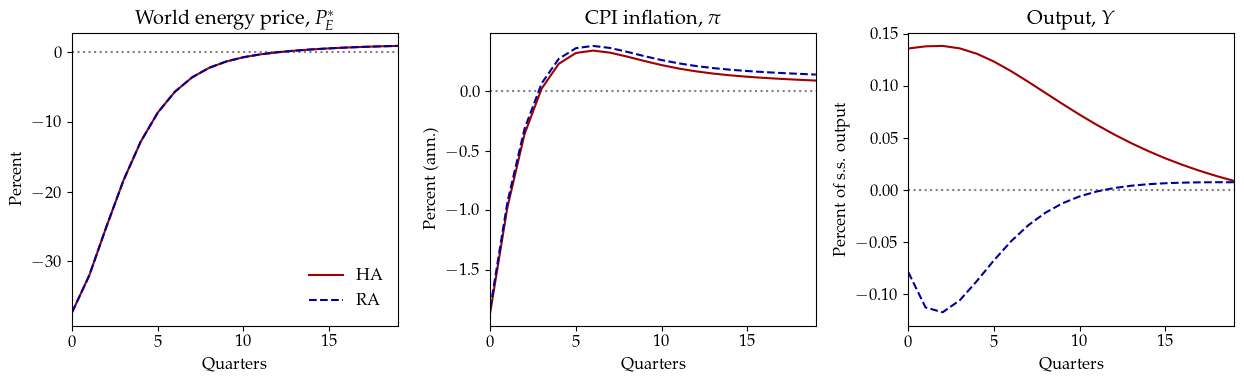

In [85]:
# Response to other energy importers doing the 2pp real rate hike with persistence 0.85 from above.

make_plot(list(ha_spill_list.values()), 
          labels = list(ha_spill_list.keys()),
          panels=np.array([['PEstar','pi_ann','y']]),
          titles=np.array([['World energy price, $P_{E}^{*}$', 'CPI inflation, $\pi$', 'Output, $Y$']]),
          legend_counter=1, leg_loc='lower right',
          #colors = [blueslide,blueslide,greenslide,greenslide],
          #linestyles=['-','--','-','--'],
          Tplot=Tplot,
          ylabels=['Percent','Percent (ann.)','Percent  of s.s. output'], 
          filename='energy_spillovers_raha'
         ) 

## Fiscal policy

In [86]:
# Degree of fiscal response
fiscal_scale = 0.5 

# Common fiscal calibration
calib_opt = dict()

# Plot options
opt = dict(Tplot=Tplot, 
           colors=[blueslide, redslide, 'purple', greenslide], 
           linestyles=['-', '--', 'dotted', 'dashdot'], 
           ylims={'pi_ann':[-2,14], 'piw_ann':[-1,7], 'y':[-3,0.5], 'C':[-3,0.5], 'B':[-1,20]})

In [87]:
ha_fiscal_list = {}
ha_fiscal_list['nothing'] = recalib(shocks, **calib_opt)
ha_fiscal_list['subsidy'] = recalib(shocks, **calib_opt, tauE=fiscal_scale)
ha_fiscal_list['targeted'] = recalib(shocks, **calib_opt, insE=fiscal_scale)
ha_fiscal_list['untargeted'] = recalib(shocks | {'epsT':ha_fiscal_list['targeted']['Ttargeted']}, **calib_opt)

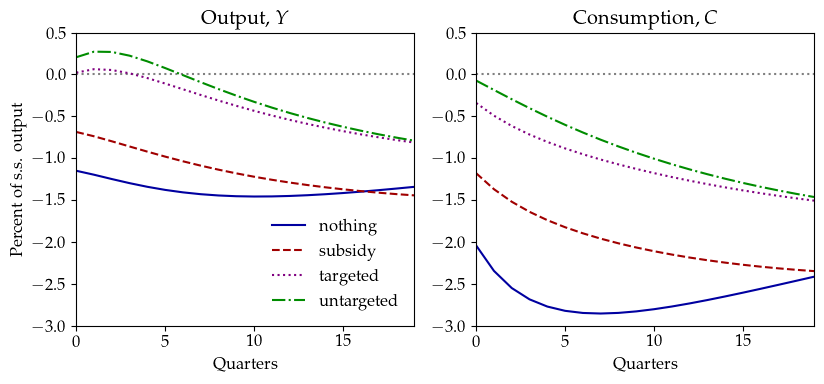

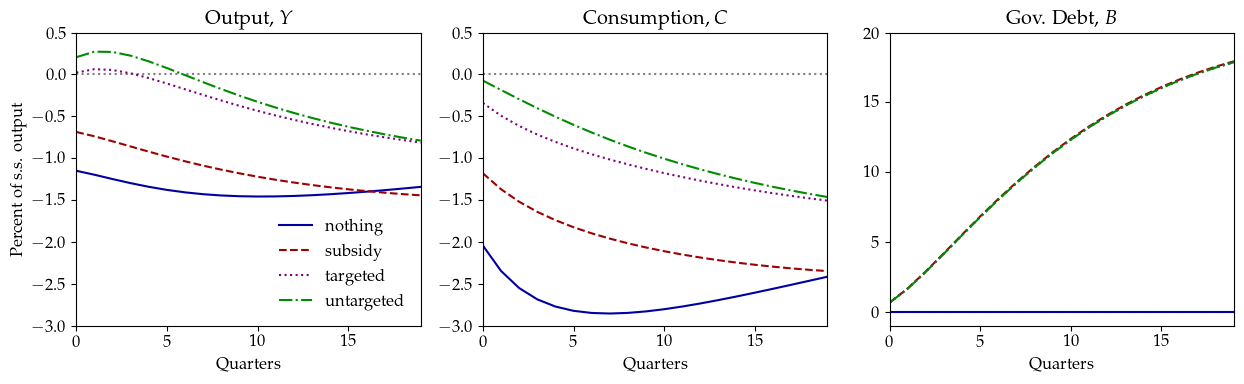

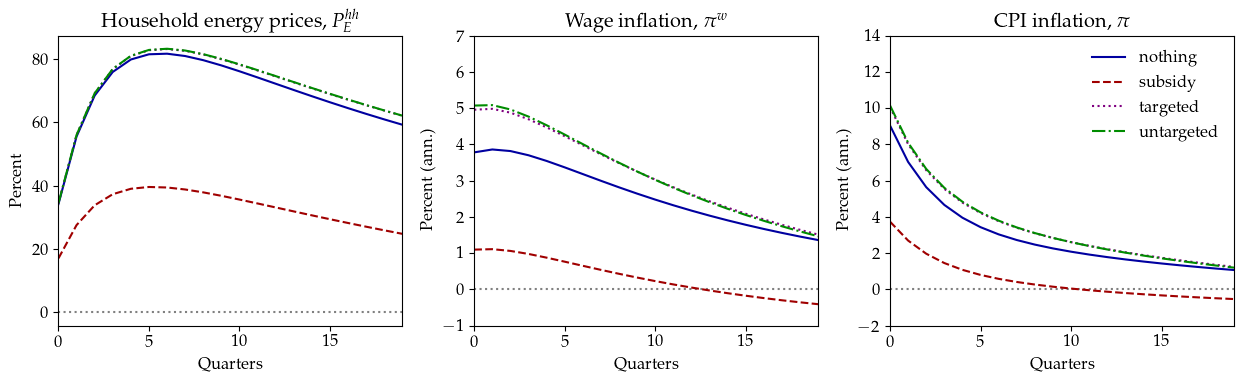

In [88]:
# Quantities plot
make_plot(list(ha_fiscal_list.values()), 
          labels=list(ha_fiscal_list.keys()),
          panels=np.array([['y', 'C']]), 
          titles=np.array([['Output, $Y$', 'Consumption, $C$']]), 
          ylabels=['Percent of s.s. output',''],
          **opt, legend_counter=1, leg_loc='lower right',
          filename='energy_fisc_real_slides') 

make_plot(list(ha_fiscal_list.values()), 
          labels=list(ha_fiscal_list.keys()),
          panels=np.array([['y', 'C', 'B']]), 
          titles=np.array([['Output, $Y$', 'Consumption, $C$', 'Gov. Debt, $B$']]), 
          ylabels=['Percent of s.s. output','',''],
          **opt, legend_counter=1, leg_loc='lower right',
          filename='energy_fisc_real') 

# Prices plot
make_plot(list(ha_fiscal_list.values()), 
          labels=list(ha_fiscal_list.keys()),
          panels=np.array([['pEhh', 'piw_ann', 'pi_ann']]), 
          titles=np.array([['Household energy prices, $P_{E}^{hh}$', 'Wage inflation, $\\pi^{w}$', 'CPI inflation, $\\pi$']]), 
          ylabels=['Percent','Percent (ann.)','Percent (ann.)'],
          **opt, legend_counter=3,
          filename='energy_fisc_prices') 

In [89]:
- np.log(2) / np.log(1+ss_ha['r']-(ss_ha.toplevel|calib_opt)['psiB']*ss_ha['w']*ss_ha['n'])

23.690173951519025

### Fiscal Coordination

In [90]:
calib_opt_E = dict(E_supply_elasticity=0, **calib_opt)

ha_fiscal_co_list = {}
ha_fiscal_co_list['nothing'] = recalib(E_shock, **calib_opt_E)
ha_fiscal_co_list['subsidy'] = recalib(E_shock, **calib_opt_E, tauE=fiscal_scale)
ha_fiscal_co_list['targeted'] = recalib(E_shock, **calib_opt_E, insE=fiscal_scale)
ha_fiscal_co_list['untargeted'] = recalib(E_shock | {'epsT':ha_fiscal_co_list['targeted']['Ttargeted']}, **calib_opt_E)

#### Uncoordinated

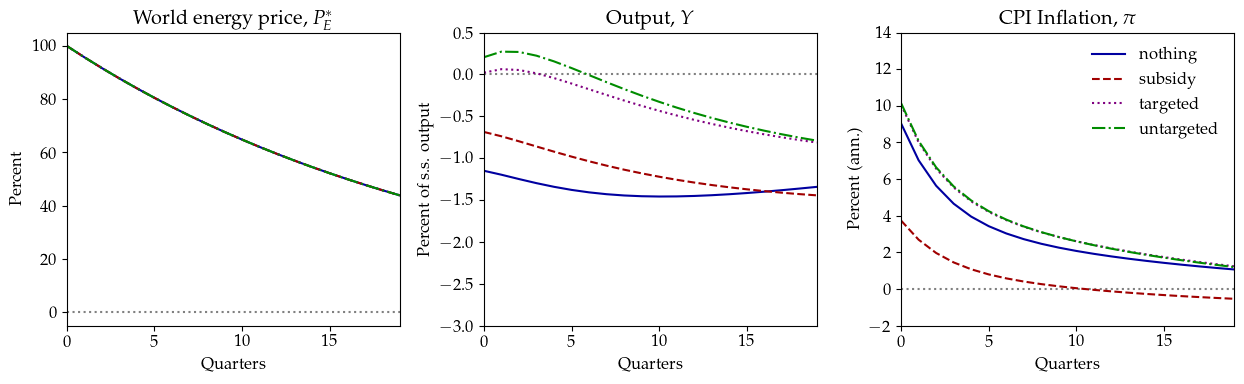

In [91]:
make_plot(list(ha_fiscal_list.values()), 
          labels=list(ha_fiscal_list.keys()),
          panels=np.array([['PEstar', 'y', 'pi_ann']]), 
          titles=np.array([['World energy price, $P_{E}^{*}$', 'Output, $Y$', 'CPI Inflation, $\pi$']]), 
          ylabels=['Percent','Percent of s.s. output','Percent (ann.)'],
          **opt, legend_counter=3,
          filename='energy_fisc_nocoop')

#### Coordinated

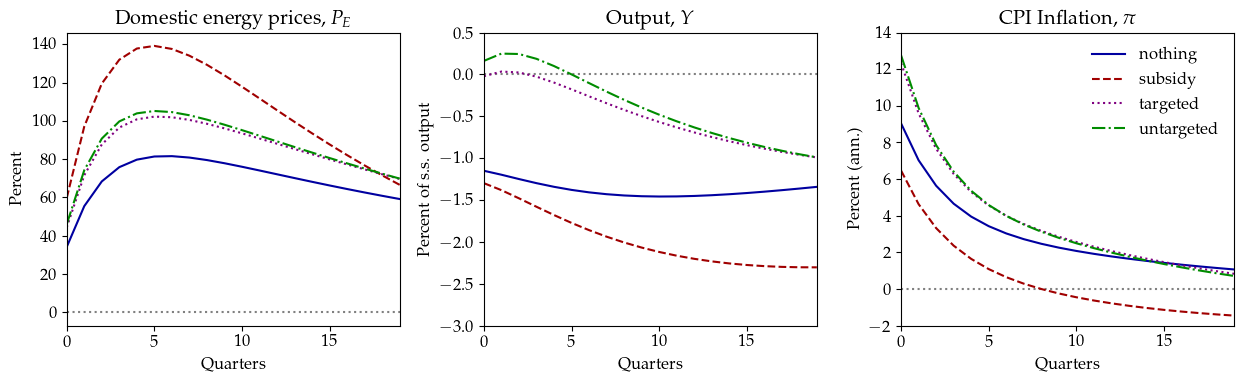

In [92]:
make_plot(list(ha_fiscal_co_list.values()), 
          labels=list(ha_fiscal_co_list.keys()),
          panels=np.array([['PE', 'y', 'pi_ann']]), 
          titles=np.array([['Domestic energy prices, $P_{E}$', 'Output, $Y$', 'CPI Inflation, $\pi$']]), 
          ylabels=['Percent','Percent of s.s. output','Percent (ann.)'],
          **opt, legend_counter=3,
          filename='energy_fisc_coop')

### Inequality

In [93]:
# In steady state:
EV = np.mean([np.tensordot(ss_ha.internals[f'hh_{i}']['D'],ss_ha.internals[f'hh_{i}']['logc2']) - np.tensordot(ss_ha.internals[f'hh_{i}']['D'],ss_ha.internals[f'hh_{i}']['logc'])**2 for i in range(3)])
VE = np.var([np.tensordot(ss_ha.internals[f'hh_{i}']['D'],ss_ha.internals[f'hh_{i}']['logc']) for i in range(3)])
EV - VE

0.25856800874701

In [94]:
def get_c_ineq(irf_dict):
    for (k,irf) in irf_dict.items():
        EV = np.mean([irf[f'C2_{i}'] - (irf[f'C_{i}'] ** 2) for i in range(3)],axis=0)
        VE = np.var([irf[f'C_{i}'] for i in range(3)],axis=0)
        irf_dict[k]['VARC'] = EV - VE

        EV = np.mean([irf[f'LOGC2_{i}'] - irf[f'LOGC_{i}'] ** 2 for i in range(3)],axis=0)
        VE = np.var([irf[f'LOGC_{i}'] for i in range(3)],axis=0)
        irf_dict[k]['VARLOGC'] = EV - VE
    return irf_dict

In [95]:
ha_fiscal_list = get_c_ineq(ha_fiscal_list)
ha_fiscal_co_list = get_c_ineq(ha_fiscal_co_list)

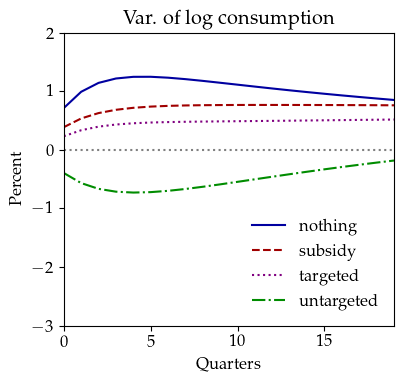

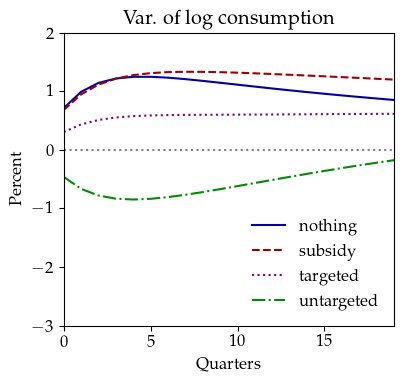

In [96]:
opt_here = opt | dict(panels=np.array([['VARLOGC']]), titles=np.array([['Var. of log consumption']]), leg_loc='lower right', ylims=[[-3,2]])

make_plot(list(ha_fiscal_list.values()), 
          labels=list(ha_fiscal_co_list.keys()),
          filename='energy_fisc_nocoop_welfare', 
          **opt_here)

make_plot(list(ha_fiscal_co_list.values()), 
          labels=list(ha_fiscal_co_list.keys()),
          filename='energy_fisc_coop_welfare',
          **opt_here)

#n.b. these are multiplied by 100, as other plots

### Balanced budget

In [97]:
calib_opt = dict(bb=1)

ha_fiscal_bb_list = {}
ha_fiscal_bb_list['nothing'] = recalib(shocks, **calib_opt)
ha_fiscal_bb_list['subsidy'] = recalib(shocks, **calib_opt, tauE=fiscal_scale)
ha_fiscal_bb_list['targeted'] = recalib(shocks, **calib_opt, insE=fiscal_scale)
ha_fiscal_bb_list['untargeted'] = recalib(shocks | {'epsT':ha_fiscal_bb_list['targeted']['Ttargeted']}, **calib_opt)

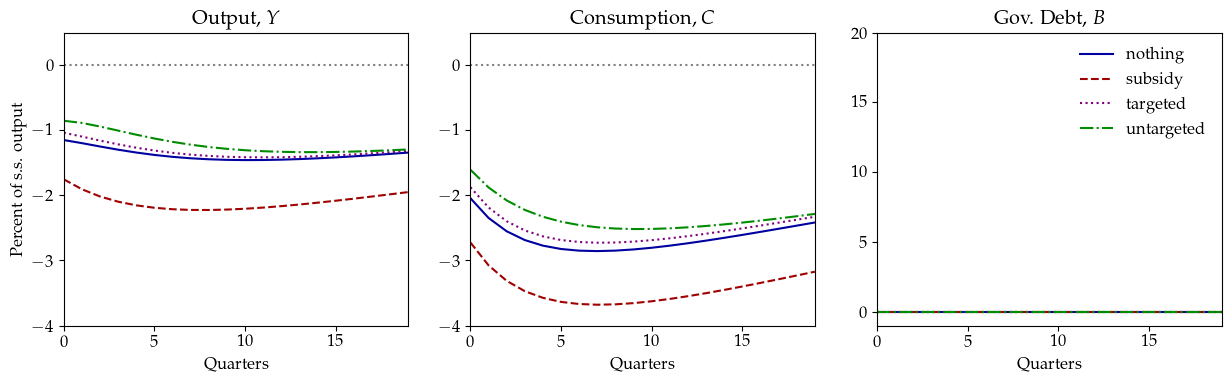

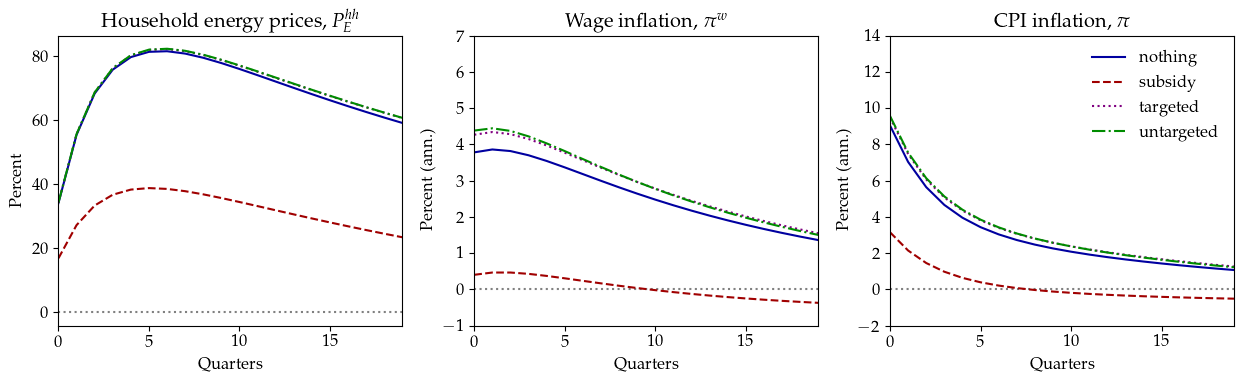

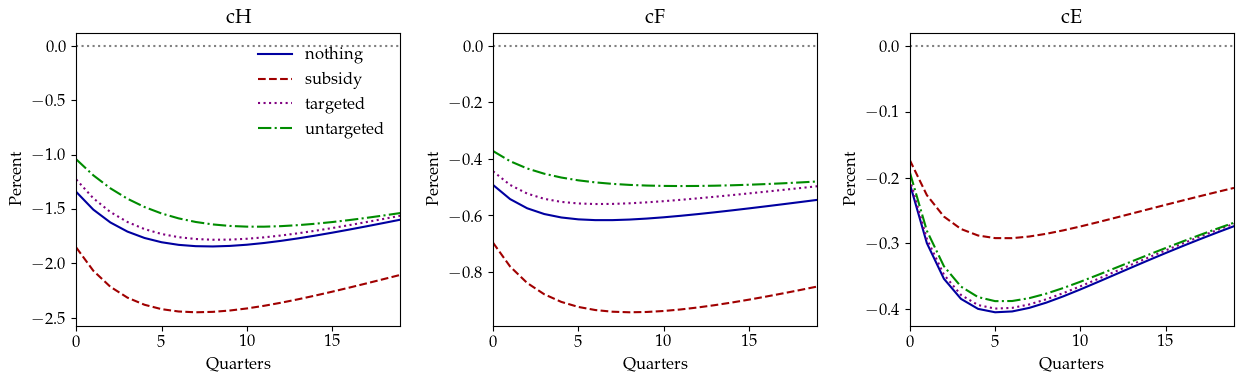

In [98]:
make_plot(list(ha_fiscal_bb_list.values()), 
          labels=list(ha_fiscal_bb_list.keys()),
          panels=np.array([['y', 'C', 'B']]), 
          titles=np.array([['Output, $Y$', 'Consumption, $C$', 'Gov. Debt, $B$']]), 
          ylabels=['Percent of s.s. output','','','',''],
          **opt | dict(ylims={'pi_ann':[-2,14], 'piw_ann':[-1,7], 'y':[-4,0.5], 'C':[-4,0.5], 'B':[-1,20]}), legend_counter=3, leg_loc='upper right',
          filename='energy_fisc_bb_real') 

make_plot(list(ha_fiscal_bb_list.values()), 
          labels=list(ha_fiscal_bb_list.keys()),
          panels=np.array([['pEhh', 'piw_ann', 'pi_ann']]), 
          titles=np.array([['Household energy prices, $P_{E}^{hh}$', 'Wage inflation, $\\pi^{w}$', 'CPI inflation, $\\pi$']]), 
          ylabels=['Percent','Percent (ann.)','Percent (ann.)','',''],
          **opt, legend_counter=3,
          filename='energy_fisc_bb_prices') 

make_plot(list(ha_fiscal_bb_list.values()), 
          labels=list(ha_fiscal_bb_list.keys()),
          panels=np.array([['cH', 'cF', 'cE']]), **opt) 